# DIRISA SDC 2026: Electoral participation in Mpumalanga

**Problem statement.** Turnout in Mpumalanga's local government elections fell from 56.4% in 2016 to 42.8% in 2021 (IEC results, team calculation). Ahead of the 4 November 2026 elections, only about half of Mpumalanga's eligible 18-29-year-olds are on the voters' roll. At the same time, the Auditor-General keeps reporting weak financial management in several of the province's municipalities. These pieces of evidence sit in separate IEC, Census and Auditor-General sources, so it is hard to see *where* participation is at risk and *why*.

**Our question.** *Which Mpumalanga municipalities and voting districts are most at risk of low turnout in 2026, how much of that risk comes from registration gaps versus turnout gaps, where does a young voters' roll overlap with historically low turnout, and how does municipal performance relate to participation?*

**Who it is for:** the IEC and civil society (targeting voter education), journalists (which areas to watch), and municipalities and parties (where registration isn't turning into votes).

| Part | Method | Answers |
|---|---|---|
| A | Turnout forecast (machine learning, backtested on 2016 and 2021) | Which areas are most at risk of low turnout in 2026 |
| B | Registration gap vs turnout gap (calculated) | Is the problem registration, or voting? |
| C | Socio-economic factors (rank correlations; model feature importance) | Which living conditions, education levels and audit records go with low participation |
| D | Participation profiles and priority list | Where youth, low turnout and weak municipal performance overlap |

**Notebook map.** Each stage is completed and checked before the next one is added.

| Stage | Purpose | Status |
|---|---|---|
| 1 | Environment, metadata, source checks and raw ingestion | Ready |
| 2 | Mpumalanga election panel (voting district x election x ballot, 2000-2021), 2021 boundaries, reconciliation with IEC | Ready |
| 3 | Census 2022 indicators, registration denominators and Auditor-General audit outcomes | Ready |
| 4 | Exploratory analysis and feature engineering | Ready |
| 5 | Models: turnout forecast (A), registration vs turnout gap (B), socio-economic factors (C), profiles and priority list (D) | Ready |
| 6 | Dashboard | Next |

**Scope:** Mpumalanga only (team decision), 17 local municipalities on 2021 boundaries. Data rules are in `metadata/README.md`. Raw files are never modified, and every derived table goes to `derived/`.

**How to run**
1. Nothing to download: the large inputs are unpacked automatically from `DATASETS/compressed/` by cell 1.3.
2. Select a kernel that has the packages in `requirements.txt` (the project `.venv` is recommended). Cell 1.1 checks this and tells you exactly what to install if something is missing.
3. **Restart the kernel, then Run All.** The whole notebook takes about 5-6 minutes. Cell 1.6 loads a 487 MB file (about 1.5 minutes): let it finish.
4. Cells depend on earlier cells, so always run from the top. Each stage checks that the previous one ran and says so if it didn't.

**How each cell is documented:** every code cell starts with a header block: **WHAT** it does, **WHY** it matters, **HOW TO READ / LOOK FOR** in its output, and **SAVED AS** for files it writes.

## Stage 1: Environment, metadata and raw ingestion

Checks the environment, loads the metadata that governs every input, confirms every source file exists, records checksums, and loads the core raw tables at their original grain. Nothing is cleaned, joined or modelled here.

In [1]:
# =====================================================================================
# 1.1 Environment and configuration
# -------------------------------------------------------------------------------------
# WHAT:  Imports the libraries, sets the folders, and fixes the project scope.
# WHY:   Everything later depends on these settings. The package check stops the notebook
#        early, with the exact fix, if the selected Python lacks a required package.
# LOOK FOR: "Packages : all required packages found". Any Python with these packages works;
#        the project .venv (see README) is the recommended one.
# =====================================================================================
from pathlib import Path
from datetime import datetime, timezone
import csv
import shutil
import zipfile
import hashlib
import importlib.metadata
import importlib.util
import io
import json
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import ListedColormap, BoundaryNorm
import joblib
from sklearn.cluster import KMeans
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits

# Run the model libraries single-threaded. On this Windows setup, parallel OpenMP threads
# made gradient boosting stall; the data is small, so one thread is fast and reproducible.
threadpool_limits(limits=1)

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

RANDOM_SEED = 2026
PROJECT_ROOT = Path.cwd()
METADATA_DIR = PROJECT_ROOT / 'metadata'
DATASETS_DIR = PROJECT_ROOT / 'DATASETS'
DERIVED_DIR = PROJECT_ROOT / 'derived'
DERIVED_DIR.mkdir(exist_ok=True)

# Team decision: the analysis covers Mpumalanga only (17 municipalities, 2021 boundaries)
SCOPE_PROVINCE = 'Mpumalanga'
SCOPE_CENSUS_PROVINCE_CODE = 8          # Stats SA province code for Mpumalanga
SCOPE_MUNICIPALITIES = 17

def require(*names, stage):
    """Stop with a clear message if a stage is run before the stage it depends on."""
    missing = [n for n in names if n not in globals()]
    if missing:
        raise RuntimeError(f"{', '.join(missing)} not found: run {stage} first. Easiest: Restart the kernel, then Run All.")

print(f'Project root : {PROJECT_ROOT}')
print(f'Python       : {sys.version.split()[0]} | pandas: {pd.__version__} | numpy: {np.__version__}')
print(f'Scope        : {SCOPE_PROVINCE} ({SCOPE_MUNICIPALITIES} municipalities)')

# Any Python works as long as it has the packages below (the project .venv is recommended).
REQUIRED_PACKAGES = {'pandas': 'pandas', 'numpy': 'numpy', 'openpyxl': 'openpyxl', 'pyarrow': 'pyarrow',
                     'matplotlib': 'matplotlib', 'sklearn': 'scikit-learn'}   # import name: pip name
on_project_venv = Path(sys.prefix).resolve() == (PROJECT_ROOT / '.venv').resolve()
print(f'Kernel       : {sys.executable}' + ('  (project .venv)' if on_project_venv else '  (not the project .venv; fine while all packages are present)'))
missing_packages = [pip for mod, pip in REQUIRED_PACKAGES.items() if importlib.util.find_spec(mod) is None]
if missing_packages:
    raise ModuleNotFoundError(
        f'This Python is missing: {missing_packages}. Either pick the project .venv as kernel, or run this in the '
        f'VS Code Terminal (not in a cell):  "{sys.executable}" -m pip install {" ".join(missing_packages)}')
print('Packages     : all required packages found')

Project root : C:\Users\User\Downloads\DIRISA_PROJECT-main\DIRISA_PROJECT-github
Python       : 3.13.6 | pandas: 3.0.6 | numpy: 2.5.3
Scope        : Mpumalanga (17 municipalities)
Kernel       : C:\Users\User\Downloads\DIRISA_PROJECT-main\DIRISA_PROJECT-github\.venv\Scripts\python.exe  (project .venv)
Packages     : all required packages found


In [2]:
# =====================================================================================
# 1.2 Source files
# -------------------------------------------------------------------------------------
# WHAT:  Lists every file the pipeline reads, and checks they all exist.
# WHY:   One place to see all inputs. If a file is missing, we find out now, not halfway
#        through the notebook.
# LARGE FILES: the four files over GitHub's 100 MB limit are stored zipped in
#        DATASETS/compressed/ and unpacked by the next cell (1.3) on a fresh clone.
# NOTE:  The 2000/2006 results come from the baseline file, which covers all provinces.
#        It must stay whole because Bushbuckridge (MP325) was counted under Limpopo in 2000.
# =====================================================================================
SOURCES = {
    # metadata
    'metadata_source_registry': METADATA_DIR / 'source_registry.csv',
    'metadata_data_dictionary': METADATA_DIR / 'data_dictionary.csv',
    'metadata_geo_crosswalk':   METADATA_DIR / 'geography_crosswalk.csv',
    'metadata_census_codebook': METADATA_DIR / 'census2022_household_codebook_derived.csv',
    'metadata_readme':          METADATA_DIR / 'README.md',
    # IEC election results
    'baseline_lge_master':      DATASETS_DIR / 'iec_results' / 'LGE_All_Sources_Master_721327_Rows.csv',  # 2000 and 2006 (+ MP 2011-2021 cross-check)
    'lge_2011_mp':              DATASETS_DIR / 'iec_results' / 'local_elections' / 'MP_LGE_2011.csv',
    'lge_2016_mp':              DATASETS_DIR / 'iec_results' / 'local_elections' / 'MP_LGE_2016.csv',
    'lge_2021_mp':              DATASETS_DIR / 'iec_results' / 'local_elections' / 'MP_LGE_2021.csv',
    'iec_official_turnout_dir': DATASETS_DIR / 'iec_results' / 'official_turnout_reports',              # official MP turnout reports (checks)
    'npe_turnout_mp':           DATASETS_DIR / 'iec_results' / 'provincial_elections' / 'Mpumalanga_Voter_Turnout_2004-2024.csv',
    # registration
    'voters_2026_report':       DATASETS_DIR / 'iec_registration' / '2026 Registered voters.xlsx',
    'youth_registration_2026':  DATASETS_DIR / 'iec_registration' / 'youth_registration_variables_national.csv',  # IEC dashboard; MP selected in Stage 3
    # Census 2022 (all provinces kept in the files; Mpumalanga selected in Stage 3)
    'census_households':        DATASETS_DIR / 'census2022' / 'Census2022_F18_F19_Combined_full.csv',
    'census_persons':           DATASETS_DIR / 'census2022' / 'raw' / 'Census2022sample_F21.csv',
    'census_geography':         DATASETS_DIR / 'census2022' / 'raw' / 'Census2022sample_F18.csv',
    # municipal performance: Auditor-General audit outcomes (National Treasury Municipal Money API)
    'agsa_audit_mp':            DATASETS_DIR / 'auditor_general' / 'audit_opinions_mpumalanga_raw.json',
    'agsa_audit_mp322_mp323':   DATASETS_DIR / 'auditor_general' / 'audit_opinions_mp322_mp323_raw.json',
}
print(f'{len(SOURCES)} sources listed.')

18 sources listed.


In [3]:
# =====================================================================================
# 1.3 Unpack the large data files (only does work on a fresh clone) and check all inputs
# -------------------------------------------------------------------------------------
# WHAT:  GitHub rejects files over 100 MB, so the four large inputs are stored as zip
#        files in DATASETS/compressed/. If an input is missing, it is unpacked here
#        (about 1-2 minutes, once). Then every source file is checked.
# WHY:   Anyone who clones the repository can press Run All without fetching data by hand.
# LOOK FOR: "All N sources found." If a file is still missing, the error names it.
# =====================================================================================
COMPRESSED = {                       # source key -> zip file in DATASETS/compressed/
    'baseline_lge_master': 'LGE_All_Sources_Master_721327_Rows.csv.zip',
    'census_households':   'Census2022_F18_F19_Combined_full.csv.zip',
    'census_persons':      'Census2022sample_F21.csv.zip',
    'census_geography':    'Census2022sample_F18.csv.zip',
}
for key, zip_name in COMPRESSED.items():
    target = SOURCES[key]
    if target.exists():
        print(f'present   {target.relative_to(PROJECT_ROOT)}')
        continue
    zip_path = DATASETS_DIR / 'compressed' / zip_name
    print(f'unpacking {zip_path.relative_to(PROJECT_ROOT)} -> {target.relative_to(PROJECT_ROOT)} ...')
    target.parent.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as zf, zf.open(zf.namelist()[0]) as src, open(target, 'wb') as dst:
        shutil.copyfileobj(src, dst, 16 * 1024 * 1024)

missing = {k: str(v) for k, v in SOURCES.items() if not v.exists()}
if missing:
    raise FileNotFoundError(f'Missing inputs: {missing}')
print(f'All {len(SOURCES)} sources found.')

present   DATASETS\iec_results\LGE_All_Sources_Master_721327_Rows.csv
present   DATASETS\census2022\Census2022_F18_F19_Combined_full.csv
present   DATASETS\census2022\raw\Census2022sample_F21.csv
present   DATASETS\census2022\raw\Census2022sample_F18.csv
All 18 sources found.


In [4]:
# =====================================================================================
# 1.4 Metadata (loaded before any data)
# -------------------------------------------------------------------------------------
# WHAT:  Loads the source registry (what each file is), the data dictionary, the
#        geography crosswalk and the Census codebook (what each Census code means).
# WHY:   The rules for using each dataset are visible at runtime, not hidden in our heads.
# =====================================================================================
source_registry     = pd.read_csv(SOURCES['metadata_source_registry'], dtype='string')
data_dictionary     = pd.read_csv(SOURCES['metadata_data_dictionary'], dtype='string')
geography_crosswalk = pd.read_csv(SOURCES['metadata_geo_crosswalk'], dtype='string')
census_codebook     = pd.read_csv(SOURCES['metadata_census_codebook'], keep_default_na=False)

assert source_registry['source_id'].is_unique
assert not census_codebook.duplicated(['variable', 'code']).any(), 'each census code must map to one label'
display(source_registry[['source_id', 'filename', 'status']])

,source_id,filename,status
0,baseline_lge_master,DATASETS/iec_results/LGE_All_Sources_Master_72...,approved-for-audit-not-modeling
1,voters_2026_report,DATASETS/iec_registration/2026 Registered vote...,quarantine-until-profiled
2,census_2022_f18_f19,DATASETS/census2022/Census2022_F18_F19_Combine...,approved-for-aggregation-with-rules
3,baseline_iec_source_registry,Qualifier-listed IEC resources,metadata-required
4,iec_2026_registration_press_figures,DATASETS/reference/iec_2026_registration_press...,approved-for-context-not-modeling
5,census_2022_raw_f18,DATASETS/census2022/raw/Census2022sample_F18.c...,approved-for-audit-not-modeling
6,census_2022_raw_f19,DATASETS/census2022/raw/Census2022sample_F19.c...,quarantine-until-codebook
7,census_2022_raw_f21,DATASETS/census2022/raw/Census2022sample_F21.c...,quarantine-until-codebook
8,lge_2011_results,DATASETS/iec_results/local_elections/MP_LGE_20...,approved-for-audit-not-modeling
9,lge_2016_results,DATASETS/L2 (deleted: Mpumalanga-only scope),retired-scope-change


In [5]:
# =====================================================================================
# 1.5 Input manifest (fingerprints of the input files)
# -------------------------------------------------------------------------------------
# WHAT:  Records each main input's size, date and SHA-256 "fingerprint".
# WHY:   Reproducibility. If anyone changes a file, the fingerprint changes, so we can
#        prove which exact data produced our results.
# SAVED AS: derived/stage1_input_manifest.csv
# =====================================================================================
def sha256_file(path: Path, chunk_size: int = 8 * 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()

manifest_keys = ['baseline_lge_master', 'lge_2011_mp', 'lge_2016_mp', 'lge_2021_mp', 'npe_turnout_mp', 'voters_2026_report',
                 'census_households', 'agsa_audit_mp']
input_manifest = pd.DataFrame([
    {'input': k,
     'path': str(SOURCES[k].relative_to(PROJECT_ROOT)),
     'bytes': SOURCES[k].stat().st_size,
     'modified_utc': datetime.fromtimestamp(SOURCES[k].stat().st_mtime, tz=timezone.utc).isoformat(timespec='seconds'),
     'sha256': sha256_file(SOURCES[k])}
    for k in manifest_keys
])
input_manifest.to_csv(DERIVED_DIR / 'stage1_input_manifest.csv', index=False)
display(input_manifest)

,input,path,bytes,modified_utc,sha256
0,baseline_lge_master,DATASETS\iec_results\LGE_All_Sources_Master_72...,486717424,2026-09-24T19:34:26+00:00,7e5b97e4a3f1f288cce49eb0f7f37d8dd573de702b3485...
1,lge_2011_mp,DATASETS\iec_results\local_elections\MP_LGE_20...,5380494,2026-09-24T19:08:13+00:00,c4108c71a2444882337d2da4addd0f0727ffbafaae5765...
2,lge_2016_mp,DATASETS\iec_results\local_elections\MP_LGE_20...,7347435,2026-09-24T19:08:13+00:00,1f62d4c02568c5eb12aaebacf0141516380f7fe958d471...
3,lge_2021_mp,DATASETS\iec_results\local_elections\MP_LGE_20...,9041631,2026-09-24T19:08:14+00:00,564cef51184a64a451d6e75be226e3d8ed635b6698f80a...
4,npe_turnout_mp,DATASETS\iec_results\provincial_elections\Mpum...,11294,2026-09-24T19:08:14+00:00,0c3c0b7401a057ccab923113a97976404e0fea00d7a184...
5,voters_2026_report,DATASETS\iec_registration\2026 Registered vote...,22065,2026-09-24T19:08:13+00:00,832400cc46576850aaeaab877af9db37910e6704391f84...
6,census_households,DATASETS\census2022\Census2022_F18_F19_Combine...,136682377,2026-09-24T19:34:27+00:00,721d8a06b1c411323a9c440066316bd30e78e057a06661...
7,agsa_audit_mp,DATASETS\auditor_general\audit_opinions_mpumal...,78701,2026-09-24T19:08:13+00:00,3f0944aa82ce7f326eb74342802a61e90fc47cb8cc1d9d...


### Raw ingestion

The tables below stay at source grain. Later stages create new objects and never overwrite these.

In [6]:
# =====================================================================================
# 1.6 IEC results baseline (2000-2021)
# -------------------------------------------------------------------------------------
# WHAT:  Loads the team's combined IEC results file: one row per party x ballot x voting
#        district, which is why it has 721,327 rows.
# WHY:   It is our only source for 2000 and 2006. For 2011-2021 we read the original IEC
#        Mpumalanga files in Stage 2 and use the baseline to cross-check them.
# NOTE:  The source files "MP 2016.csv" and "MP 2021.csv" had their years swapped. The
#        baseline corrected this from each file's DateGenerated (column year_label_corrected).
# TAKES: about 1.5 minutes (487 MB file).
# =====================================================================================
baseline_raw = pd.read_csv(SOURCES['baseline_lge_master'], low_memory=False,
                           na_values=['', 'NA', 'N/A', 'null', 'None'])
print(f'baseline_raw: {baseline_raw.shape[0]:,} rows x {baseline_raw.shape[1]} columns')
display(baseline_raw.groupby(['election_year', 'source_filename']).agg(
    rows=('record_id', 'size'), provinces=('province', 'nunique'), municipalities=('municipality_code', 'nunique')))
assert baseline_raw.loc[baseline_raw['year_label_corrected'], 'source_filename'].isin(['MP 2016.csv', 'MP 2021.csv']).all()

baseline_raw: 721,327 rows x 48 columns


,,rows,provinces,municipalities
election_year,source_filename,,,
2000,2000 LGE.zip,199566,9,262
2006,2006 LGE.zip,374695,9,257
2011,MP 2011.csv,34066,1,18
2016,MP 2021.csv,50723,1,17
2021,MP 2016.csv,62277,1,17


In [7]:
# =====================================================================================
# 1.7 2026 registered voters workbook (IEC)
# -------------------------------------------------------------------------------------
# WHAT:  Loads the Excel report as-is. It holds several small tables on one sheet
#        (by province, by age and gender, and by Mpumalanga municipality).
# WHY:   A cross-check for the 2026 registration figures used in Stage 3.
# NOTE:  Its label "MP314 - Emlahleni" is a typo for Emakhazeni (fixed in the crosswalk).
# =====================================================================================
voters_report_raw = pd.read_excel(SOURCES['voters_2026_report'], sheet_name=0, header=None, dtype=object)
print(f'voters_report_raw: {voters_report_raw.shape}')
display(voters_report_raw.head(15))

voters_report_raw: (39, 10)


,0,1,2,3,4,5,6,7,8,9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Registered Voters by province,NaN,NaN,Registered voters demographic by age-group and...,NaN,NaN,NaN,NaN,NaN,NaN
3,Provinces,Reg_Voters,NaN,NaN,NaN,NaN,NaN,NaN,Overall,NaN
4,Eastern Cape,3627731,NaN,NaN,Gender,NaN,NaN,Gender,Percentages,Total
5,Free State,1533038,NaN,Age_group,Male,Female,NaN,Males,0.452199,981126
6,Gauteng,6749751,NaN,18 - 19,311130,388850,NaN,Females,0.547801,1188553
7,Kwazulu-natal,6028841,NaN,20 - 29,2157224,2686296,NaN,NaN,NaN,NaN
8,Mpumalanga,2169679,NaN,30 - 39,3120250,3658421,NaN,NaN,NaN,NaN
9,Northern Cape,713681,NaN,40 - 49,2994058,3316801,NaN,NaN,NaN,NaN


In [8]:
# =====================================================================================
# 1.8 Census 2022 households (10% sample)
# -------------------------------------------------------------------------------------
# WHAT:  Loads every sampled household (1,338,295) with its municipality, living
#        conditions (coded) and household weight HH_WGT.
# WHY:   Provides the socio-economic context (internet, water, hunger...) in Stage 3.
# NOTE:  The file is kept whole (team decision). Mpumalanga (province code 8) is selected
#        in Stage 3. Official household counts use conventional dwellings only (codes 1-2).
# =====================================================================================
census_raw = pd.read_csv(SOURCES['census_households'], low_memory=False)
print(f'census_raw: {census_raw.shape[0]:,} households x {census_raw.shape[1]} columns (all provinces)')
assert len(census_raw) == 1_338_295 and census_raw['QID'].is_unique

conventional = census_raw['H01_QUARTERS'].isin([1, 2])
in_scope = census_raw['Province'].eq(SCOPE_CENSUS_PROVINCE_CODE)
print(f"Weighted households, all provinces (conventional dwellings): {census_raw.loc[conventional, 'HH_WGT'].sum():,.0f}  (published: 17.8 million)")
print(f"Weighted households, {SCOPE_PROVINCE}: {census_raw.loc[conventional & in_scope, 'HH_WGT'].sum():,.0f} "
      f"from {int((conventional & in_scope).sum()):,} sampled households")

census_raw: 1,338,295 households x 36 columns (all provinces)
Weighted households, all provinces (conventional dwellings): 17,822,722  (published: 17.8 million)
Weighted households, Mpumalanga: 1,421,415 from 96,878 sampled households


In [9]:
# =====================================================================================
# 1.9 Stage 1 summary
# =====================================================================================
stage1_summary = pd.DataFrame([
    {'object': 'baseline_raw',      'rows': len(baseline_raw),      'columns': baseline_raw.shape[1]},
    {'object': 'voters_report_raw', 'rows': len(voters_report_raw), 'columns': voters_report_raw.shape[1]},
    {'object': 'census_raw',        'rows': len(census_raw),        'columns': census_raw.shape[1]},
])
display(stage1_summary)
print('Stage 1 complete: metadata and raw inputs loaded; nothing transformed.')

,object,rows,columns
0,baseline_raw,721327,48
1,voters_report_raw,39,10
2,census_raw,1338295,36


Stage 1 complete: metadata and raw inputs loaded; nothing transformed.


## Stage 2: Mpumalanga election panel

Builds one table with **one row per voting district x election x ballot type**, then maps every voting district onto the **2021 municipal boundaries** so municipalities can be compared across elections.

| Election | Source |
|---|---|
| 2000, 2006 | `baseline_raw` (all provinces; Mpumalanga selected after mapping, so Bushbuckridge's 2000 districts, counted under Limpopo then, are kept) |
| 2011 | `DATASETS/iec_results/local_elections/MP_LGE_2011.csv` |
| 2016 | `DATASETS/iec_results/local_elections/MP_LGE_2016.csv` |
| 2021 | `DATASETS/iec_results/local_elections/MP_LGE_2021.csv` |

All ballot types (PR, Ward, DC 40%) are kept. Turnout later follows the IEC rule: the higher of the PR or Ward votes cast.

In [10]:
# =====================================================================================
# 2.1 Read the original IEC result files for Mpumalanga (2011, 2016, 2021)
# -------------------------------------------------------------------------------------
# WHAT:  Reads each IEC file (one row per party x ballot x voting district) into one
#        table with clean column names and numbers.
# WHY:   These are the official detailed results. Every number is checked: the file's
#        generated date must match its election, and all rows must be Mpumalanga.
# OUTPUT: results_long (party-level rows)
# =====================================================================================
require('SOURCES', 'baseline_raw', stage='Stage 1')

RESULT_FILES = {2011: SOURCES['lge_2011_mp'], 2016: SOURCES['lge_2016_mp'], 2021: SOURCES['lge_2021_mp']}
BALLOT_NAMES = {'PR': 'PR', 'WARD': 'WARD', 'DC 40%': 'DC40', 'DMA DC 60%': 'DMA_DC60'}

def read_iec_results(path: Path, election_year: int) -> pd.DataFrame:
    """Read one IEC detailed-results file (handles UTF-16 and UTF-8) into the standard layout."""
    raw = path.read_bytes()
    encoding = 'utf-16' if raw[:2] in (b'\xff\xfe', b'\xfe\xff') else 'utf-8-sig'
    df = pd.read_csv(io.StringIO(raw.decode(encoding)), dtype=str)
    df.columns = df.columns.str.strip()
    generated = pd.to_datetime(df['DateGenerated'], format='%m/%d/%Y %I:%M:%S %p')
    assert set(generated.dt.year) == {election_year}, (path.name, set(generated.dt.year))   # right election?
    out = pd.DataFrame({
        'election_year': election_year,
        'province': df['Province'].str.strip(),
        'municipality_source': df['Municipality'].str.strip(),
        'ward': df['Ward'].str.replace('Ward', '', regex=False).str.strip(),
        'voting_district': df['VotingDistrict'].str.strip(),
        'ballot_type': df['BallotType'].str.strip().str.upper().map(BALLOT_NAMES),
        'party_name': df['PartyName'].str.strip(),
        'source_file': str(path.relative_to(PROJECT_ROOT)),
    })
    for src, dst in [('RegisteredVoters', 'registered_voters'), ('SpoiltVotes', 'spoilt_votes'), ('TotalValidVotes', 'party_valid_votes')]:
        out[dst] = pd.to_numeric(df[src], errors='raise').astype('int64')   # errors='raise': stop on any non-number
    assert out['ballot_type'].notna().all(), f'unknown ballot type in {path.name}'
    return out

results_long = pd.concat([read_iec_results(p, y) for y, p in RESULT_FILES.items()], ignore_index=True)
assert (results_long['province'] == SCOPE_PROVINCE).all()
display(results_long.groupby('election_year').agg(rows=('party_name', 'size'), municipalities=('municipality_source', 'nunique'),
                                                   voting_districts=('voting_district', 'nunique')))

,rows,municipalities,voting_districts
election_year,,,
2011,34066,18,1565
2016,50723,17,1744
2021,62277,17,1785


In [11]:
# =====================================================================================
# 2.2 Add 2000 and 2006 from the baseline (all provinces for now)
# -------------------------------------------------------------------------------------
# WHAT:  Converts the 2000/2006 baseline rows to the same layout as 2.1.
# WHY:   Boundaries changed a lot since 2000. Bushbuckridge (today MP325) was a
#        cross-border council counted under LIMPOPO in 2000. So we keep all provinces
#        here and select Mpumalanga AFTER mapping to 2021 boundaries (cell 2.5).
# MISSING VALUE: one 2000 row (Mdala Nature Reserve, a district management area) has
#        spoilt votes recorded as NULL at source. It is set to 0 and printed below.
# =====================================================================================
early = baseline_raw.loc[baseline_raw['election_year'].isin([2000, 2006])]
missing_spoilt = early['spoilt_votes'].isna()
print(f'Rows with spoilt votes recorded as NULL at source (set to 0): {int(missing_spoilt.sum())}')
display(early.loc[missing_spoilt, ['election_year', 'municipality_source', 'voting_district', 'ballot_type', 'registered_voters']])
early_long = pd.DataFrame({
    'election_year': early['election_year'].astype(int),
    'province': early['province'].str.strip(),
    'municipality_source': early['municipality_source'].str.strip(),
    'ward': early['ward_source'].fillna('').astype(str).str.strip(),   # district management areas have no wards
    'voting_district': early['voting_district'].astype(str).str.strip(),
    'ballot_type': early['ballot_type'].str.strip().str.upper().map(BALLOT_NAMES),
    'party_name': early['party_name'],
    'source_file': 'LGE_All_Sources_Master_721327_Rows.csv (' + early['source_filename'] + ')',
    'registered_voters': early['registered_voters'].astype('int64'),
    'spoilt_votes': early['spoilt_votes'].fillna(0).astype('int64'),
    'party_valid_votes': early['party_valid_votes'].astype('int64'),
})
assert early_long['ballot_type'].notna().all()
results_long = pd.concat([early_long, results_long], ignore_index=True)
print(f'results_long: {len(results_long):,} party rows across {results_long.election_year.nunique()} elections')

Rows with spoilt votes recorded as NULL at source (set to 0): 1


,election_year,municipality_source,voting_district,ballot_type,registered_voters
160845,2000,MPDMA31 [Mdala Nature Reserve],54580226,WARD,25.0


results_long: 721,327 party rows across 5 elections


In [12]:
# =====================================================================================
# 2.3 Collapse party rows: one row per voting district x election x ballot
# -------------------------------------------------------------------------------------
# WHAT:  Adds up each party's valid votes, and keeps registered voters and spoilt votes
#        (these repeat on every party row, so they must be identical: checked here).
#        votes_cast = valid votes + spoilt votes.
# WHY:   The model works per voting district, not per party.
# LOOK FOR: "conflicting repeated values: 0" (the data is internally consistent).
# NOTE:  A few districts have more votes than registered voters. That is normal: people
#        on another station's roll can vote with an MEC7 form.
# =====================================================================================
KEY = ['election_year', 'voting_district', 'ballot_type']
consistency = results_long.groupby(KEY).agg(
    registered_values=('registered_voters', 'nunique'), spoilt_values=('spoilt_votes', 'nunique'),
    municipalities=('municipality_source', 'nunique'), wards=('ward', 'nunique'))
problems = consistency[(consistency > 1).any(axis=1)]
print(f'Voting district x ballot groups with conflicting repeated values: {len(problems)} of {len(consistency):,}')

vd_panel = (results_long.groupby(KEY, as_index=False)
            .agg(province=('province', 'first'), municipality_source=('municipality_source', 'first'), ward=('ward', 'first'),
                 registered_voters=('registered_voters', 'max'), spoilt_votes=('spoilt_votes', 'max'),
                 valid_votes=('party_valid_votes', 'sum'), parties=('party_name', 'nunique'), source_file=('source_file', 'first')))
vd_panel['votes_cast'] = vd_panel['valid_votes'] + vd_panel['spoilt_votes']
vd_panel['municipality_code'] = vd_panel['municipality_source'].str.split(' - ').str[0].str.strip()
vd_panel['turnout_pct'] = 100 * vd_panel['votes_cast'] / vd_panel['registered_voters'].where(vd_panel['registered_voters'] > 0)
assert not vd_panel.duplicated(KEY).any()
print(f"vd_panel: {len(vd_panel):,} rows (all provinces for 2000/2006, Mpumalanga for 2011-2021)")

Voting district x ballot groups with conflicting repeated values: 0 of 109,806


vd_panel: 109,806 rows (all provinces for 2000/2006, Mpumalanga for 2011-2021)


In [13]:
# =====================================================================================
# 2.4 Cross-check: original IEC files vs the team baseline (Mpumalanga 2011-2021)
# -------------------------------------------------------------------------------------
# WHAT:  Compares voting districts, registered voters and votes cast between the two.
# WHY:   Two independent copies of the same results must agree exactly. If they do, we
#        can trust both, including the baseline's 2000/2006 data.
# LOOK FOR: "agree exactly". The cell stops with an error if they don't.
# =====================================================================================
check = []
for year in (2011, 2016, 2021):
    ours = vd_panel[(vd_panel.election_year == year) & (vd_panel.ballot_type == 'PR')]
    base = (baseline_raw[(baseline_raw.election_year == year) & (baseline_raw.ballot_type.str.upper() == 'PR')]
            .drop_duplicates('voting_district'))
    check.append({'election_year': year, 'vds_raw': len(ours), 'vds_baseline': len(base),
                  'registered_raw': ours.registered_voters.sum(), 'registered_baseline': int(base.registered_voters.sum()),
                  'votes_cast_raw': ours.votes_cast.sum(), 'votes_cast_baseline': int(base.ballot_votes_cast.sum())})
baseline_check = pd.DataFrame(check)
display(baseline_check)
assert (baseline_check.vds_raw == baseline_check.vds_baseline).all()
assert (baseline_check.registered_raw == baseline_check.registered_baseline).all()
assert (baseline_check.votes_cast_raw == baseline_check.votes_cast_baseline).all()
print('Original IEC files and baseline agree exactly for 2011, 2016 and 2021.')

,election_year,vds_raw,vds_baseline,registered_raw,registered_baseline,votes_cast_raw,votes_cast_baseline
0,2011,1565,1565,1718309,1718309,957839,957839
1,2016,1744,1744,1919216,1919216,1073679,1073679
2,2021,1785,1785,1902220,1902220,807551,807551


Original IEC files and baseline agree exactly for 2011, 2016 and 2021.


### Mapping voting districts onto 2021 municipal boundaries

Boundaries changed between elections (for example MP322 Mbombela and MP323 Umjindi merged into MP326 City of Mbombela in 2016). Each earlier voting district is assigned to the 2021 Mpumalanga municipality it falls in:

1. **VD code match**: the voting district code also exists in 2021, so it takes that district's 2021 municipality.
2. **Municipality majority**: the code no longer exists (districts get re-drawn), so it takes the 2021 municipality that received most of its old municipality's matched voters. This rule is used only if **at least half** of the old municipality's voters matched into today's Mpumalanga by code.
3. **Outside Mpumalanga today**: neither rule points to a 2021 Mpumalanga municipality (other provinces, and areas that moved to Limpopo, such as CBLC3-5 Marble Hall, Groblersdal and Tubatse in 2000). These are dropped.

In [14]:
# =====================================================================================
# 2.5 Map every voting district to its 2021 Mpumalanga municipality, then keep Mpumalanga
# -------------------------------------------------------------------------------------
# WHAT:  Applies the two rules above, then keeps only districts inside today's Mpumalanga.
# WHY:   So "MP326 in 2006" means the same land as "MP326 in 2021", and trends over time
#        are fair comparisons.
# LOOK FOR: (1) the share of voters mapped by exact code (should be ~99%);
#           (2) Bushbuckridge's 2000 districts arriving from "Limpopo";
#           (3) old Mpumalanga areas that now belong to Limpopo (dropped).
# =====================================================================================
vd_2021 = (vd_panel[vd_panel.election_year == 2021].sort_values('ballot_type')
           .groupby('voting_district').agg(municipality_code_2021=('municipality_code', 'first'),
                                           municipality_name_2021=('municipality_source', 'first'),
                                           province_2021=('province', 'first'), n_munis=('municipality_code', 'nunique')))
assert (vd_2021.n_munis == 1).all(), 'a 2021 voting district must sit in exactly one municipality'
vd_2021 = vd_2021.drop(columns='n_munis')

# one row per voting district per election, weighted by its registered voters (largest ballot)
vd_year = (vd_panel.groupby(['election_year', 'voting_district'], as_index=False)
           .agg(municipality_code=('municipality_code', 'first'), municipality_source=('municipality_source', 'first'),
                province=('province', 'first'), registered_voters=('registered_voters', 'max')))
vd_year = vd_year.merge(vd_2021, left_on='voting_district', right_index=True, how='left')
vd_year['boundary_method'] = np.where(vd_year['municipality_code_2021'].notna(), 'vd_code_match', None)

# Rule 2: old municipality -> the 2021 municipality that received most of its matched voters
matched = vd_year[vd_year.boundary_method.eq('vd_code_match')]
flows = matched.groupby(['election_year', 'municipality_code', 'municipality_code_2021'], as_index=False)['registered_voters'].sum()
flows['share'] = flows['registered_voters'] / flows.groupby(['election_year', 'municipality_code'])['registered_voters'].transform('sum')
majority = flows.sort_values('share', ascending=False).drop_duplicates(['election_year', 'municipality_code'])
# Guard: only use rule 2 if at least HALF of the old municipality's voters matched into today's
# Mpumalanga by code. Otherwise most of it now lies in another province (e.g. CBLC4 Groblersdal in
# 2000: only 0.6% matched), and its unmatched districts must not be pulled into Mpumalanga.
old_total = vd_year.groupby(['election_year', 'municipality_code'])['registered_voters'].sum()
matched_total = matched.groupby(['election_year', 'municipality_code'])['registered_voters'].sum()
matched_share = (matched_total / old_total).rename('matched_into_scope_share').reset_index()
majority = majority.merge(matched_share, on=['election_year', 'municipality_code'])
print('Old municipalities NOT given the majority rule (less than half their voters are in today\'s Mpumalanga):')
display(majority[majority['matched_into_scope_share'] < 0.5][['election_year', 'municipality_code', 'matched_into_scope_share']])
majority = majority[majority['matched_into_scope_share'] >= 0.5]
need = vd_year['boundary_method'].isna()
fill = vd_year.loc[need, ['election_year', 'municipality_code']].merge(
    majority[['election_year', 'municipality_code', 'municipality_code_2021']], how='left', on=['election_year', 'municipality_code'])
vd_year.loc[need, 'municipality_code_2021'] = fill['municipality_code_2021'].to_numpy()
vd_year.loc[need & vd_year['municipality_code_2021'].notna(), 'boundary_method'] = 'municipality_majority'
vd_year['boundary_method'] = vd_year['boundary_method'].fillna('outside_mpumalanga_2021')
names_2021 = vd_2021.drop_duplicates('municipality_code_2021').set_index('municipality_code_2021')
vd_year['municipality_name_2021'] = vd_year['municipality_code_2021'].map(names_2021['municipality_name_2021'])
vd_year['province_2021'] = vd_year['municipality_code_2021'].map(names_2021['province_2021'])

# Keep only districts that are in Mpumalanga today
vd_year_mp = vd_year[vd_year['province_2021'].eq(SCOPE_PROVINCE)].copy()
coverage = (vd_year_mp.groupby(['election_year', 'boundary_method'])['registered_voters'].sum()
            .unstack(fill_value=0).pipe(lambda t: 100 * t.div(t.sum(axis=1), axis=0)).round(2))
print('Share of registered voters in today\'s Mpumalanga, by mapping method (%):')
display(coverage)
print('Districts in today\'s Mpumalanga that were counted under ANOTHER province at the time:')
display(vd_year_mp[vd_year_mp.province != SCOPE_PROVINCE].groupby(['election_year', 'province', 'municipality_source'])['voting_district'].nunique())
left = vd_year[(vd_year.province == SCOPE_PROVINCE) & vd_year['province_2021'].ne(SCOPE_PROVINCE)]
print('Mpumalanga districts at the time that are NOT in Mpumalanga today (dropped):')
display(left.groupby(['election_year', 'municipality_source']).agg(voting_districts=('voting_district', 'nunique'),
                                                                   registered_voters=('registered_voters', 'sum')))

Old municipalities NOT given the majority rule (less than half their voters are in today's Mpumalanga):


,election_year,municipality_code,matched_into_scope_share
1,2000,CBLC4,0.005915
22,2000,MPDMA32 [DMA Lowveld],0.234375


Share of registered voters in today's Mpumalanga, by mapping method (%):


boundary_method,municipality_majority,vd_code_match
election_year,,
2000,1.04,98.96
2006,0.44,99.56
2011,0.32,99.68
2016,0.21,99.79
2021,0.00,100.00


Districts in today's Mpumalanga that were counted under ANOTHER province at the time:


election_year  province  municipality_source                  
2000           Limpopo   CBDMA4 [Kruger Park]                       4
                         CBLC6 - Bushbuckridge [Bushbuckridge]    184
Name: voting_district, dtype: int64

Mpumalanga districts at the time that are NOT in Mpumalanga today (dropped):


voting_districts  registered_voters
election_year municipality_source                                                                    
2000          CBDMA3 [Schuinsdraai Nature Reserve]                               1                 14
              CBLC3 - Greater Marble Hall [Marble Hall]                         43              43374
              CBLC4 - Greater Groblersdal [Groblersdal]                         77              92605
              CBLC5 - Greater Tubatse [Burgersfort/Ohrigstad/...               104              97033
              MPDMA32 [DMA Lowveld]                                              4                147

In [15]:
# =====================================================================================
# 2.6 Municipality x election x ballot table (2021 boundaries, Mpumalanga only)
# -------------------------------------------------------------------------------------
# WHAT:  Attaches the 2021 municipality to every voting-district row, drops districts
#        outside today's Mpumalanga, and adds everything up per municipality.
# LOOK FOR: 17 municipalities in every election (2000-2021).
# OUTPUT: vd_panel (now Mpumalanga only) and muni_panel
# =====================================================================================
vd_panel = vd_panel.merge(vd_year[['election_year', 'voting_district', 'municipality_code_2021', 'municipality_name_2021',
                                   'province_2021', 'boundary_method']], on=['election_year', 'voting_district'], how='left')
vd_panel = vd_panel[vd_panel['province_2021'].eq(SCOPE_PROVINCE)].reset_index(drop=True)

muni_panel = (vd_panel.groupby(['province_2021', 'municipality_code_2021', 'municipality_name_2021', 'election_year', 'ballot_type'], as_index=False)
              .agg(registered_voters=('registered_voters', 'sum'), votes_cast=('votes_cast', 'sum'), valid_votes=('valid_votes', 'sum'),
                   spoilt_votes=('spoilt_votes', 'sum'), voting_districts=('voting_district', 'nunique'),
                   share_vd_code_match=('boundary_method', lambda s: (s == 'vd_code_match').mean())))
muni_panel['turnout_pct'] = 100 * muni_panel['votes_cast'] / muni_panel['registered_voters']
muni_panel['spoilt_pct'] = 100 * muni_panel['spoilt_votes'] / muni_panel['votes_cast']
assert not muni_panel.duplicated(['municipality_code_2021', 'election_year', 'ballot_type']).any()
munis_per_year = muni_panel[muni_panel.ballot_type == 'PR'].groupby('election_year')['municipality_code_2021'].nunique()
display(munis_per_year.rename('municipalities').to_frame())
assert (munis_per_year == SCOPE_MUNICIPALITIES).all()
print(f"vd_panel (Mpumalanga): {len(vd_panel):,} rows | muni_panel: {len(muni_panel):,} rows")

,municipalities
election_year,
2000,17
2006,17
2011,17
2016,17
2021,17


vd_panel (Mpumalanga): 21,993 rows | muni_panel: 261 rows


In [16]:
# =====================================================================================
# 2.7 Reconciliation with the official IEC Mpumalanga turnout reports (2011, 2016, 2021)
# -------------------------------------------------------------------------------------
# WHAT:  Compares our registered voters and turnout per municipality with the IEC's own
#        published turnout reports.
# WHY:   Proves our processing reproduces official figures.
# HOW:   IEC turnout = max(PR, Ward) votes cast / (registered + MEC7 votes). MEC7 counts
#        are only in the official reports, so we add them here for the comparison.
# LOOK FOR: registered and turnout votes exact for (almost) every municipality.
#        Known exception: MP325 in 2021 (official report printed later than the results file).
# =====================================================================================
def turnout_iec_style(frame, group):
    """Turnout votes = the larger of PR and Ward votes cast in each voting district."""
    wide = frame.pivot_table(index=group + ['voting_district'], columns='ballot_type', values='votes_cast', aggfunc='sum')
    reg = frame.groupby(group + ['voting_district'])['registered_voters'].max()
    t = pd.DataFrame({'registered': reg, 'turnout_votes': wide[['PR', 'WARD']].max(axis=1)}).groupby(group).sum()
    t['turnout_pct'] = 100 * t['turnout_votes'] / t['registered']
    return t

def read_iec_turnout_report(path: Path) -> pd.DataFrame:
    """Pull the municipality lines out of the IEC's report-style CSV."""
    rows = []
    for fields in csv.reader(path.read_text(encoding='latin-1').splitlines()):
        vals = [f.strip() for f in fields if f.strip()]
        if vals and re.match(r'^[A-Z]{2,3}\d{0,3} - ', vals[0]) and len(vals) >= 5:
            rows.append({'municipality_code_2021': vals[0].split(' - ')[0], 'official_registered': int(vals[1].replace(',', '')),
                         'official_mec7': int(vals[2].replace(',', '')), 'official_turnout_votes': int(vals[3].replace(',', '')),
                         'official_turnout_pct': float(vals[4].rstrip('%'))})
    return pd.DataFrame(rows)

recon = []
for year in (2011, 2016, 2021):
    official = read_iec_turnout_report(SOURCES['iec_official_turnout_dir'] / f'MP_turnout_{year}.csv')
    ours = turnout_iec_style(vd_panel[vd_panel.election_year == year], ['municipality_code']).reset_index()
    ours = ours.rename(columns={'municipality_code': 'municipality_code_2021'})
    m = official.merge(ours, on='municipality_code_2021', how='outer', indicator=True)
    m['election_year'] = year
    recon.append(m)
recon_mp = pd.concat(recon, ignore_index=True)
recon_mp['registered_diff'] = recon_mp['registered'] - recon_mp['official_registered']
recon_mp['turnout_votes_diff'] = recon_mp['turnout_votes'] - recon_mp['official_turnout_votes']
recon_mp['turnout_pct_with_mec7'] = 100 * recon_mp['turnout_votes'] / (recon_mp['registered'] + recon_mp['official_mec7'])
recon_mp['pct_diff_pp'] = recon_mp['turnout_pct_with_mec7'] - recon_mp['official_turnout_pct']
summary = recon_mp.groupby('election_year').agg(
    municipalities=('municipality_code_2021', 'size'), matched=('_merge', lambda s: (s == 'both').sum()),
    registered_exact=('registered_diff', lambda s: (s == 0).sum()), turnout_votes_exact=('turnout_votes_diff', lambda s: (s == 0).sum()),
    max_abs_pct_diff_pp=('pct_diff_pp', lambda s: s.abs().max()))
display(summary)
display(recon_mp.loc[(recon_mp.registered_diff != 0) | (recon_mp.turnout_votes_diff != 0),
                     ['election_year', 'municipality_code_2021', 'official_registered', 'registered', 'official_turnout_votes', 'turnout_votes', 'pct_diff_pp']])

,municipalities,matched,registered_exact,turnout_votes_exact,max_abs_pct_diff_pp
election_year,,,,,
2011,18,18,18,18,0.004783
2016,17,17,17,17,0.004752
2021,17,17,16,16,0.175996


,election_year,municipality_code_2021,official_registered,registered,official_turnout_votes,turnout_votes,pct_diff_pp
50,2021,MP325,246357,245338,106536,106530,0.175996


In [17]:
# =====================================================================================
# 2.8 National/provincial election turnout per municipality (2004-2024)
# -------------------------------------------------------------------------------------
# WHAT:  Loads the team's table of provincial-election turnout per Mpumalanga
#        municipality (compiled from the IEC's municipal turnout reports, file column
#        "src") and puts it on 2021 boundaries:
#          - MP322 Mbombela + MP323 Umjindi are added together as MP326 City of Mbombela
#          - 2004 cross-border areas (CBLC2-5, CBDMA3-4) and district management areas
#            are not part of any 2021 Mpumalanga municipality, so they are dropped
# WHY:   A national/provincial election sits between two local elections. 2024 is the
#        most recent turnout signal before the 2026 local election. National turnout is
#        always higher than local turnout, so the model uses it as a relative signal.
# LOOK FOR: all five provincial elections present (2004, 2009, 2014, 2019, 2024). Each
#        local election then uses the provincial election held 2 years before it.
#        2019 was added from the IEC report provincial_elections/MP_Provincial_Turnout_2019.xls.
# NOTE:  turnout = votes / registered voters (column "reg"). One row (2014 MP302) has a
#        different "pop" figure; "reg" is used throughout, consistent with other years.
# =====================================================================================
npe_raw = pd.read_csv(SOURCES['npe_turnout_mp'])
TO_2021_CODE = {'MP322': 'MP326', 'MP323': 'MP326'}      # 2016 merger
npe_raw['municipality_code_2021'] = npe_raw['code'].replace(TO_2021_CODE)
mp_codes_2021 = set(muni_panel['municipality_code_2021'])
dropped = npe_raw[~npe_raw['municipality_code_2021'].isin(mp_codes_2021)]
print('Rows not part of a 2021 Mpumalanga municipality (dropped):')
display(dropped[['year', 'code', 'name', 'reg', 'votes', 'note']])

npe_muni = (npe_raw[npe_raw['municipality_code_2021'].isin(mp_codes_2021)]
            .groupby(['year', 'municipality_code_2021'])[['reg', 'votes']].sum())
npe_muni['npe_turnout_pct'] = 100 * npe_muni['votes'] / npe_muni['reg']
npe_turnout = npe_muni['npe_turnout_pct'].unstack('year')          # rows = municipality, columns = election year
print('Provincial-election turnout per municipality (2021 boundaries):')
display(npe_turnout.round(1))
expected_npe_years = {2004, 2009, 2014, 2019, 2024}
missing_years = sorted(expected_npe_years - set(npe_turnout.columns))
if missing_years:
    print(f'WARNING: provincial elections missing from the file: {missing_years}. Features fall back to the latest earlier election.')

Rows not part of a 2021 Mpumalanga municipality (dropped):


,year,code,name,reg,votes,note
0,2004,CBDMA3,Schuinsdraai Nature Reserve,25,0,Cross-boundary municipality (2004); District M...
1,2004,CBDMA4,Kruger Park,2556,1776,Cross-boundary municipality (2004); District M...
2,2004,CBLC2,Kungwini,17599,13442,Cross-boundary municipality (2004)
3,2004,CBLC3,Greater Marble Hall,21840,15982,Cross-boundary municipality (2004)
4,2004,CBLC4,Greater Groblersdal,60872,45996,Cross-boundary municipality (2004)
5,2004,CBLC5,Greater Tubatse,13897,10660,Cross-boundary municipality (2004)
23,2004,MPDMA31,Mdala Nature Reserve,17,43,District Management Area; Votes exceed registe...
24,2004,MPDMA32,DMA Lowveld,1460,1063,District Management Area
43,2009,MPDMA32,Kruger Park,2329,1879,District Management Area


Provincial-election turnout per municipality (2021 boundaries):


year,2004,2009,2014,2019,2024
municipality_code_2021,,,,,
MP301,80.4,78.3,74.6,63.4,58.5
MP302,80.1,82.6,77.9,66.7,61.0
MP303,75.7,76.7,74.1,62.1,59.9
MP304,77.3,75.5,73.3,62.7,60.5
MP305,78.7,79.8,75.2,64.5,59.1
MP306,77.0,77.4,73.2,63.9,58.5
MP307,76.4,78.2,73.9,63.9,58.8
MP311,76.5,78.8,75.4,65.1,57.3
MP312,75.8,77.9,74.9,65.5,57.7


In [18]:
# =====================================================================================
# 2.9 Save Stage 2 outputs
# -------------------------------------------------------------------------------------
# SAVES: derived/election_vd_panel.parquet  (voting district x election x ballot, Mpumalanga)
#        derived/vd_to_2021_municipality_map.csv
#        derived/municipality_election_panel_2021_boundaries.csv
#        derived/reconciliation_mp_official_turnout.csv
#        derived/npe_turnout_municipality.csv (provincial elections, 2021 boundaries)
# =====================================================================================
vd_panel.to_parquet(DERIVED_DIR / 'election_vd_panel.parquet', index=False)
vd_year_mp.to_csv(DERIVED_DIR / 'vd_to_2021_municipality_map.csv', index=False)
muni_panel.to_csv(DERIVED_DIR / 'municipality_election_panel_2021_boundaries.csv', index=False)
recon_mp.drop(columns='_merge').to_csv(DERIVED_DIR / 'reconciliation_mp_official_turnout.csv', index=False)
npe_muni.round(3).to_csv(DERIVED_DIR / 'npe_turnout_municipality.csv')
for f in ['election_vd_panel.parquet', 'vd_to_2021_municipality_map.csv', 'municipality_election_panel_2021_boundaries.csv',
          'reconciliation_mp_official_turnout.csv', 'npe_turnout_municipality.csv']:
    print(f'{f:52s} {(DERIVED_DIR / f).stat().st_size:>12,} bytes')
print('Stage 2 complete.')

election_vd_panel.parquet                                 366,987 bytes
vd_to_2021_municipality_map.csv                           852,740 bytes
municipality_election_panel_2021_boundaries.csv            31,629 bytes
reconciliation_mp_official_turnout.csv                      5,923 bytes
npe_turnout_municipality.csv                                2,713 bytes
Stage 2 complete.


## Stage 3: Socio-economic context, registration denominators and municipal performance

Four municipal-level building blocks for Mpumalanga's 17 municipalities:

| Cell | Building block | Source |
|---|---|---|
| 3.1 | **Living conditions**: internet, household goods, water, electricity, sanitation, refuse, housing, hunger, settlement type | Census 2022 households |
| 3.2 | **Eligible voters**: adult South African citizens, aged to each voters' roll date by birth year and month | Census 2022 persons |
| 3.3 | **Education and age structure**: matric or higher, higher education, no schooling, youth share of adults | Census 2022 persons |
| 3.4 | **Registration rates**: registered voters / eligible citizens, overall and for youth (18-29) vs 30+ | IEC results (2021), IEC dashboard (2026) |
| 3.5 | **Municipal performance**: Auditor-General audit outcome per financial year | National Treasury Municipal Money |

Census rules (see `metadata/README.md`): conventional dwellings only, always weighted, and Unspecified / Not applicable answers left out of numerator and denominator (each household indicator carries `*_answered_pct`). Census geography type: 1 = Urban, 2 = Traditional, 3 = Farms. Employment and income are not available in the Census 10% sample (withheld by Stats SA).

In [19]:
# =====================================================================================
# 3.1 Census household indicators per Mpumalanga municipality
# -------------------------------------------------------------------------------------
# WHAT:  For each municipality, the % of households with internet, piped water,
#        electricity, weekly refuse removal, adult hunger and so on.
# HOW:   (1) only conventional dwellings (matches official counts);
#        (2) every household counts by its weight HH_WGT (it represents ~10 households);
#        (3) "Unspecified" / "Not applicable" answers are left out, NOT counted as "no".
#        The *_answered_pct column shows how many households answered each question.
# LOOK FOR: 17 municipalities; answer rates (the internet/goods/hunger questions were
#        skipped by some households, which Stats SA flags as a reliability issue).
# =====================================================================================
require('census_raw', 'census_codebook', 'muni_panel', 'vd_panel', stage='Stages 1 and 2')
hh = census_raw.loc[census_raw['H01_QUARTERS'].isin([1, 2]) & census_raw['Province'].eq(SCOPE_CENSUS_PROVINCE_CODE)].copy()

# Codes that mean "no answer" for each variable, taken from the codebook rather than typed by hand
no_answer = (census_codebook[census_codebook['label'].str.contains('Unspecified|Not applicable', case=False)]
             .groupby('variable')['code'].apply(set).to_dict())

# name: (variable, codes counted as "yes", extra codes to leave out of the denominator)
HOUSEHOLD_INDICATORS = {
    'internet_any':         ('H13_INTERNET_ACCESS', {1, 2, 3, 4, 5, 6, 7, 8}, set()),
    'internet_at_home':     ('H13_INTERNET_ACCESS', {1}, set()),
    'internet_mobile_only': ('H13_INTERNET_ACCESS', {2}, set()),
    'cellphone':            ('H12_CELLPHONE', {1}, set()),
    'computer':             ('H12_COMPUTER', {1}, set()),
    'motor_car':            ('H12_MOTOR_CAR', {1}, set()),
    'piped_water_in_yard':  ('H05_WATERPIPED', {1, 2}, set()),
    'electricity_lighting': ('H10_ENERGY_LIGHTING', {1}, set()),
    'flush_toilet':         ('H08_TOILET', {1, 2}, set()),
    'refuse_weekly':        ('H11_REFUSE', {1}, set()),
    'informal_dwelling':    ('H02_MAINDWELLING', {8, 9}, set()),
    'rdp_house':            ('H04_RDP', {1}, {3}),                  # 3 = do not know
    'adult_hunger':         ('A4_ADULT_HUNGER', {3, 4, 5}, {6}),    # sometimes/often/always; 6 = no adult
    'female_headed':        ('DERH_HHSEX', {2}, set()),
}

def weighted_indicator(frame, variable, yes_codes, extra_excluded):
    """Weighted % of answering households with a 'yes' code, plus the weighted % that answered."""
    excluded = no_answer.get(variable, set()) | extra_excluded
    answered = ~frame[variable].isin(excluded)
    w = frame['HH_WGT']
    g = pd.DataFrame({'Municipality': frame['Municipality'], 'w_all': w,
                      'w_answered': w.where(answered, 0), 'w_yes': w.where(answered & frame[variable].isin(yes_codes), 0)})
    s = g.groupby('Municipality')[['w_all', 'w_answered', 'w_yes']].sum()
    return 100 * s['w_yes'] / s['w_answered'], 100 * s['w_answered'] / s['w_all']

census_muni = hh.groupby('Municipality').agg(district_code=('District', 'first'),
                                             households=('HH_WGT', 'sum'), sample_households=('QID', 'size'))
for name, (variable, yes, extra) in HOUSEHOLD_INDICATORS.items():
    census_muni[f'{name}_pct'], census_muni[f'{name}_answered_pct'] = weighted_indicator(hh, variable, yes, extra)

geo = hh.pivot_table(index='Municipality', columns='Geo_type', values='HH_WGT', aggfunc='sum', fill_value=0)
geo = 100 * geo.div(geo.sum(axis=1), axis=0)
census_muni[['urban_pct', 'traditional_pct', 'farms_pct']] = geo.reindex(columns=[1, 2, 3], fill_value=0).to_numpy()
census_muni['mean_household_size'] = hh.assign(x=hh['DERH_HSIZE'] * hh['HH_WGT']).groupby('Municipality')['x'].sum() / census_muni['households']

census_muni.index.name = 'municipality_code'
assert len(census_muni) == SCOPE_MUNICIPALITIES
print(f"{len(census_muni)} municipalities | weighted households {census_muni['households'].sum():,.0f}")
display(census_muni[[c for c in census_muni if c.endswith('_pct') and not c.endswith('answered_pct')]].round(1))

17 municipalities | weighted households 1,421,415


,internet_any_pct,internet_at_home_pct,internet_mobile_only_pct,cellphone_pct,computer_pct,motor_car_pct,piped_water_in_yard_pct,electricity_lighting_pct,flush_toilet_pct,refuse_weekly_pct,informal_dwelling_pct,rdp_house_pct,adult_hunger_pct,female_headed_pct,urban_pct,traditional_pct,farms_pct
municipality_code,,,,,,,,,,,,,,,,,
MP301,77.5,3.9,69.2,92.5,15.5,26.5,83.7,95.8,40.5,33.1,3.1,20.0,18.5,50.1,19.8,71.7,8.5
MP302,78.2,7.6,66.1,91.5,20.0,28.9,84.8,86.1,79.0,74.6,11.2,41.5,16.2,45.8,86.3,0.0,13.7
MP303,70.1,3.9,64.1,90.7,12.7,22.2,76.5,88.5,51.3,48.7,3.1,28.2,30.4,51.3,51.9,11.3,36.8
MP304,75.7,6.6,62.0,91.1,19.2,25.8,92.4,91.5,77.5,72.9,6.4,51.6,16.8,51.3,74.0,14.0,12.0
MP305,79.8,11.3,65.1,92.3,25.9,34.4,94.1,94.4,91.8,80.0,10.3,43.3,10.8,46.1,91.5,0.0,8.5
MP306,81.7,8.3,69.4,89.5,20.3,26.7,91.6,88.8,90.6,85.5,8.4,51.9,13.1,44.3,95.1,0.0,4.9
MP307,87.3,7.4,74.9,94.2,25.2,34.1,94.0,92.3,92.0,86.8,12.3,42.4,13.7,44.5,96.5,0.0,3.5
MP311,80.2,8.4,68.0,94.0,17.1,29.7,90.6,91.4,85.6,80.3,13.3,58.0,18.4,44.5,85.9,0.0,14.1
MP312,82.2,8.9,68.7,93.8,25.1,34.6,82.0,83.7,78.3,68.7,11.2,37.3,21.6,42.8,96.8,0.3,2.8


In [20]:
# =====================================================================================
# 3.2 Eligible voters: adult South African citizens per municipality
# -------------------------------------------------------------------------------------
# WHAT:  Counts citizens aged 18+ (and 18-29, 30+) in each municipality, using their
#        age ON THE DATE of each voters' roll (1 Nov 2021 and 23 Sep 2026). The age is
#        worked out from birth year and month, not the 2022 age, so someone who was
#        14 in 2022 correctly counts as 18 in 2026.
# WHY:   The denominator for the registration rate (Part B).
# NOTE:  Uses the Census person file (weights PERS_WGT). People who died or moved after
#        Feb 2022 can't be removed, so the 2026 count is somewhat too high (see the note after 3.4).
# =====================================================================================
persons = pd.read_csv(SOURCES['census_persons'],
                      usecols=['QID', 'P03_YEAR', 'P03_MONTH', 'P04_AGE', 'P10_CITIZENSHIP', 'P21_EDULEVEL', 'PERS_WGT'])
geo_f18 = pd.read_csv(SOURCES['census_geography'], usecols=['QID', 'Province', 'Municipality'])
persons = persons.merge(geo_f18, on='QID', how='left', validate='many_to_one')
assert persons['Municipality'].notna().all()
persons = persons[persons['Province'].eq(SCOPE_CENSUS_PROVINCE_CODE)]

# Age on a given date from year and month of birth; unknown month (99) is treated as mid-year
birth_month = persons['P03_MONTH'].where(persons['P03_MONTH'].between(1, 12), 7)
def age_on(year, month):
    return year - persons['P03_YEAR'] - (birth_month > month).astype(int)

ROLL_DATES = {2021: (2021, 11),   # 2021 LGE voters' roll (election 1 Nov 2021)
              2026: (2026, 9)}    # IEC registration dashboard, as of 23 Sep 2026
citizen = persons['P10_CITIZENSHIP'].eq(101)          # 101 = South Africa
print(f"Persons with citizenship unspecified: {persons['P10_CITIZENSHIP'].eq(999).mean():.2%} (left out)")

eligible = []
for roll_year, (y, m) in ROLL_DATES.items():
    age = age_on(y, m)
    for label, lo, hi in [('eligible_18plus', 18, 200), ('eligible_18_29', 18, 29), ('eligible_30plus', 30, 200)]:
        s = persons.loc[citizen & age.between(lo, hi)].groupby('Municipality')['PERS_WGT'].sum().rename(f'{label}_{roll_year}')
        eligible.append(s)
eligible = pd.concat(eligible, axis=1).fillna(0)
eligible.index.name = 'municipality_code'
display(eligible.sum().round(0).rename(f'{SCOPE_PROVINCE} total').to_frame())

Persons with citizenship unspecified: 0.22% (left out)


,Mpumalanga total
eligible_18plus_2021,3274887.0
eligible_18_29_2021,1060317.0
eligible_30plus_2021,2214570.0
eligible_18plus_2026,3713778.0
eligible_18_29_2026,1044308.0
eligible_30plus_2026,2669470.0


In [21]:
# =====================================================================================
# 3.3 Education and age structure per municipality (socio-economic context)
# -------------------------------------------------------------------------------------
# WHAT:  From the same Census person file, for adults aged 20+ (the Stats SA convention
#        for "highest level of education"):
#          matric_or_higher = Grade 12, N4-N6, or any certificate/diploma/degree with Grade 12
#          higher_education = post-school certificate, diploma or degree (codes 21-27)
#          no_schooling     = no schooling at all (code 98)
#        plus the same for young adults (20-29), and the youth share of eligible adults.
# WHY:   Education is one of the socio-economic factors our Day 1 plan set out to test.
#        Employment and income are NOT available: Stats SA withheld those Census sections.
# CODES: from the Stats SA Census 2022 person metadata (metadata/census2022_docs/05...);
#        28 other, 29 do not know, 88 not applicable and 99 unspecified are left out.
# =====================================================================================
EDU_EXCLUDED = {28, 29, 88, 99}
MATRIC_OR_HIGHER = {12, 16, 17, 18} | set(range(21, 28))
HIGHER_EDUCATION = set(range(21, 28))
NO_SCHOOLING = {98}

def weighted_share(frame, yes_codes):
    """Weighted % of people (answering the education question) whose code is in yes_codes."""
    ok = ~frame['P21_EDULEVEL'].isin(EDU_EXCLUDED)
    num = frame.loc[ok & frame['P21_EDULEVEL'].isin(yes_codes)].groupby('Municipality')['PERS_WGT'].sum()
    den = frame.loc[ok].groupby('Municipality')['PERS_WGT'].sum()
    return (100 * num / den).fillna(0)

adults20 = persons[persons['P04_AGE'].between(20, 130)]
young20 = persons[persons['P04_AGE'].between(20, 29)]
education = pd.DataFrame({
    'matric_or_higher_pct': weighted_share(adults20, MATRIC_OR_HIGHER),
    'higher_education_pct': weighted_share(adults20, HIGHER_EDUCATION),
    'no_schooling_pct': weighted_share(adults20, NO_SCHOOLING),
    'youth_matric_or_higher_pct': weighted_share(young20, MATRIC_OR_HIGHER),
    'education_answered_pct': 100 * adults20.loc[~adults20['P21_EDULEVEL'].isin(EDU_EXCLUDED)].groupby('Municipality')['PERS_WGT'].sum()
                              / adults20.groupby('Municipality')['PERS_WGT'].sum(),
    'youth_share_of_adults_pct': 100 * eligible['eligible_18_29_2026'] / eligible['eligible_18plus_2026'],
})
education.index.name = 'municipality_code'
census_muni = census_muni.drop(columns=[c for c in education.columns if c in census_muni]).join(education)
assert census_muni[education.columns].notna().all().all()
print(f"{SCOPE_PROVINCE} adults 20+: matric or higher "
      f"{np.average(education['matric_or_higher_pct'], weights=adults20.groupby('Municipality')['PERS_WGT'].sum().loc[education.index]):.1f}% (weighted)")
display(education.sort_values('matric_or_higher_pct').round(1))

Mpumalanga adults 20+: matric or higher 47.1% (weighted)


,matric_or_higher_pct,higher_education_pct,no_schooling_pct,youth_matric_or_higher_pct,education_answered_pct,youth_share_of_adults_pct
municipality_code,,,,,,
MP306,35.1,4.2,9.3,48.7,92.8,25.5
MP303,38.2,3.7,11.8,51.7,92.6,31.6
MP311,41.6,3.1,8.1,50.8,93.9,27.1
MP324,42.2,5.5,20.7,55.3,92.7,31.3
MP304,42.6,5.3,12.0,53.1,93.3,27.4
MP316,43.4,5.0,12.7,62.5,92.7,27.4
MP305,44.0,6.9,7.8,53.5,93.2,27.0
MP301,44.8,4.6,14.2,60.8,93.4,31.1
MP315,45.1,4.7,12.9,60.4,93.1,27.8


In [22]:
# =====================================================================================
# 3.4 Registration rates, 2021 and 2026 (overall, youth 18-29, older 30+)
# -------------------------------------------------------------------------------------
# WHAT:  registration rate = registered voters / eligible citizens (from 3.2).
#        2021 registered voters come from the election results (Stage 2);
#        2026 registered voters come from the IEC dashboard (23 Sep 2026), by age.
# WHY:   This is Part B, the REGISTRATION GAP, including the youth gap
#        (older rate minus youth rate, in percentage points).
# LOOK FOR: the Mpumalanga totals line and the per-municipality table.
# =====================================================================================
reg_2021 = (muni_panel[(muni_panel.election_year == 2021) & (muni_panel.ballot_type == 'PR')]
            .set_index('municipality_code_2021')['registered_voters'].rename('registered_2021'))

youth_raw = pd.read_csv(SOURCES['youth_registration_2026'], skiprows=2)   # 2 comment lines above the header
youth_raw = youth_raw[youth_raw['province'].eq(SCOPE_PROVINCE)]
youth_raw['youth_18_29'] = youth_raw['age_group'].isin(['18-19', '20-29'])
reg_2026 = youth_raw.groupby('municipality_code').agg(
    registered_2026=('registered_voters', 'sum'),
    registered_2026_18_29=('registered_voters', lambda s: s[youth_raw.loc[s.index, 'youth_18_29']].sum()))
# Cross-check against the IEC workbook loaded in Stage 1 (cell 1.7): find its Mpumalanga total line
label_cell = voters_report_raw.apply(lambda col: col.astype(str).str.contains('Total Number of Registered voters in Mpumalanga', na=False))
r_, c_ = np.argwhere(label_cell.to_numpy())[0]
workbook_total = int(voters_report_raw.iat[r_, c_ + 1])
dashboard_total = int(reg_2026['registered_2026'].sum())
print(f'2026 Mpumalanga roll: IEC dashboard {dashboard_total:,} | IEC workbook {workbook_total:,} | difference {dashboard_total - workbook_total:+,}')
assert abs(dashboard_total - workbook_total) / workbook_total < 0.001, 'the two IEC 2026 sources disagree by more than 0.1%'
assert set(reg_2026.index) == set(census_muni.index) == set(reg_2021.index), 'municipality codes must line up across sources'

registration = eligible.join(reg_2021).join(reg_2026)
registration['registration_rate_2021_pct'] = 100 * registration['registered_2021'] / registration['eligible_18plus_2021']
registration['registration_rate_2026_pct'] = 100 * registration['registered_2026'] / registration['eligible_18plus_2026']
registration['youth_registration_rate_2026_pct'] = 100 * registration['registered_2026_18_29'] / registration['eligible_18_29_2026']
registration['older_registration_rate_2026_pct'] = (100 * (registration['registered_2026'] - registration['registered_2026_18_29'])
                                                    / registration['eligible_30plus_2026'])
registration['youth_registration_gap_pp'] = registration['older_registration_rate_2026_pct'] - registration['youth_registration_rate_2026_pct']
registration['youth_share_of_roll_2026_pct'] = 100 * registration['registered_2026_18_29'] / registration['registered_2026']
registration['roll_growth_2021_2026_pct'] = 100 * (registration['registered_2026'] / registration['registered_2021'] - 1)

tot = registration.sum()
print(f"{SCOPE_PROVINCE} registration rate: 2021 {100 * tot.registered_2021 / tot.eligible_18plus_2021:.1f}% | "
      f"2026 {100 * tot.registered_2026 / tot.eligible_18plus_2026:.1f}% | "
      f"2026 youth 18-29 {100 * tot.registered_2026_18_29 / tot.eligible_18_29_2026:.1f}% vs 30+ "
      f"{100 * (tot.registered_2026 - tot.registered_2026_18_29) / tot.eligible_30plus_2026:.1f}%")
display(registration[['registration_rate_2021_pct', 'registration_rate_2026_pct', 'youth_registration_rate_2026_pct',
                      'older_registration_rate_2026_pct', 'youth_registration_gap_pp', 'youth_share_of_roll_2026_pct']]
        .sort_values('youth_registration_gap_pp', ascending=False).round(1))

2026 Mpumalanga roll: IEC dashboard 2,169,700 | IEC workbook 2,169,679 | difference +21
Mpumalanga registration rate: 2021 58.1% | 2026 58.4% | 2026 youth 18-29 41.0% vs 30+ 65.3%


,registration_rate_2021_pct,registration_rate_2026_pct,youth_registration_rate_2026_pct,older_registration_rate_2026_pct,youth_registration_gap_pp,youth_share_of_roll_2026_pct
municipality_code,,,,,,
MP306,86.6,83.6,56.0,93.1,37.1,17.0
MP307,66.8,66.3,41.0,74.9,33.8,15.7
MP313,65.0,66.0,43.0,73.4,30.5,15.8
MP315,54.6,53.4,32.3,61.6,29.3,16.8
MP316,60.4,57.3,36.2,65.3,29.1,17.3
MP305,62.3,61.6,40.6,69.4,28.7,17.8
MP312,64.9,68.8,48.8,75.5,26.7,17.9
MP314,78.6,74.8,55.7,81.2,25.5,18.8
MP303,43.2,42.8,26.9,50.2,23.3,19.8


**How to read these rates.** The denominators come from a 10% Census sample taken in February 2022, aged forward by birth date. They are estimates:

- **Deaths after February 2022 are not removed.** The 2026 eligible count is therefore too high, mostly among older adults. As a result, 2026 registration rates are *lower bounds*, and the youth-vs-older gap is *understated*, so the real gap is larger. The youth (18-29) rate is the most reliable, because youth mortality is low.
- Migration after 2022 is not captured, and people in institutions and the homeless are outside the Census sample.

In [23]:
# =====================================================================================
# 3.5 Municipal performance: Auditor-General audit outcomes
# -------------------------------------------------------------------------------------
# WHAT:  Loads each municipality's audit opinion for every financial year 2011-2024
#        (the year a financial year ENDS, in June) and turns it into a score:
#          4 = clean audit (unqualified, no findings)
#          3 = unqualified with findings ("emphasis of matter")
#          2 = qualified          1 = adverse          0 = disclaimer (worst)
#        "Outstanding" (statements not submitted) has no score and is flagged.
# WHY:   The whiteboard's "Municipal scores (performance)": does weak governance go
#        with lower participation? Used in Parts A and C.
# SOURCE: National Treasury Municipal Money API (cube audit_opinions), downloaded
#        24 Sep 2026; each row links to the Auditor-General's report.
# MP326: City of Mbombela was formed in 2016 from MP322 (Mbombela) and MP323 (Umjindi).
#        For 2011-2015 its score is the two predecessors' scores weighted by their 2011
#        registered voters.
# =====================================================================================
OPINION_SCORE ={'unqualified': 4, 'unqualified_emphasis_of_matter': 3, 'qualified': 2, 'adverse': 1, 'disclaimer': 0}

def load_audit(path):
    d = pd.DataFrame(json.loads(path.read_text(encoding='utf-8'))['data'])
    return d.rename(columns={'demarcation.code': 'municipality_code', 'demarcation.label': 'municipality_label',
                             'financial_year_end.year': 'financial_year_end', 'opinion.code': 'opinion_code',
                             'opinion.label': 'opinion', 'opinion.report_url': 'report_url'})

audit_raw = pd.concat([load_audit(SOURCES['agsa_audit_mp']), load_audit(SOURCES['agsa_audit_mp322_mp323'])], ignore_index=True)
audit_raw['audit_score'] = audit_raw['opinion_code'].map(OPINION_SCORE)     # 'outstanding' -> NaN
audit_raw['outstanding'] = audit_raw['opinion_code'].eq('outstanding')
print('Opinions:', audit_raw['opinion'].value_counts().to_dict())

# MP326 before it existed: weighted average of MP322 and MP323 (weights = 2011 registered voters)
w = (vd_panel[(vd_panel.election_year == 2011) & (vd_panel.ballot_type == 'PR') & vd_panel.municipality_code.isin(['MP322', 'MP323'])]
     .groupby('municipality_code')['registered_voters'].sum())
pred = audit_raw[audit_raw.municipality_code.isin(['MP322', 'MP323'])].pivot_table(index='financial_year_end', columns='municipality_code', values='audit_score')
mp326_early = (pred * w).sum(axis=1) / w.sum()
audit_scores = audit_raw[~audit_raw.municipality_code.isin(['MP322', 'MP323'])].pivot_table(
    index='municipality_code', columns='financial_year_end', values='audit_score')
for fy, v in mp326_early.items():
    if pd.isna(audit_scores.loc['MP326'].get(fy, np.nan)):
        audit_scores.loc['MP326', fy] = v
audit_scores = audit_scores.sort_index(axis=1)
assert len(audit_scores) == SCOPE_MUNICIPALITIES
print(f'Predecessor weights for MP326 (2011 registered voters): {w.to_dict()}')
display(audit_scores.round(1))

Opinions: {'Qualified': 97, 'Unqualified - Emphasis of Matter items': 79, 'Disclaimer of opinion': 44, 'Adverse opinion': 9, 'Unqualified - No findings': 8, 'Outstanding': 5}


Predecessor weights for MP326 (2011 registered voters): {'MP322': 254137, 'MP323': 29064}


financial_year_end,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
municipality_code,,,,,,,,,,,,,,
MP301,0.0,2.0,2.0,2.0,3.0,2.0,3.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0
MP302,3.0,0.0,0.0,0.0,0.0,2.0,2.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0
MP303,0.0,NaN,0.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0,3.0,3.0,3.0
MP304,0.0,2.0,2.0,2.0,3.0,3.0,3.0,3.0,0.0,0.0,2.0,3.0,3.0,3.0
MP305,0.0,0.0,2.0,3.0,3.0,3.0,3.0,2.0,0.0,0.0,0.0,0.0,2.0,2.0
MP306,2.0,3.0,2.0,3.0,3.0,3.0,3.0,2.0,0.0,0.0,0.0,2.0,2.0,2.0
MP307,3.0,2.0,2.0,3.0,3.0,3.0,3.0,0.0,NaN,0.0,2.0,2.0,2.0,2.0
MP311,4.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,2.0,2.0
MP312,2.0,NaN,0.0,0.0,0.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0


In [24]:
# =====================================================================================
# 3.6 Save Stage 3 outputs
# -------------------------------------------------------------------------------------
# SAVES: derived/census2022_municipality_indicators.csv  (living conditions)
#        derived/registration_denominators_2021_2026.csv  (eligible citizens, rates, youth gap)
#        derived/agsa_audit_scores.csv                      (audit score per municipality x year)
#        derived/agsa_audit_opinions_long.csv               (raw opinions with report links)
# =====================================================================================
census_muni.round(3).to_csv(DERIVED_DIR / 'census2022_municipality_indicators.csv')
registration.round(3).to_csv(DERIVED_DIR / 'registration_denominators_2021_2026.csv')
audit_scores.round(3).to_csv(DERIVED_DIR / 'agsa_audit_scores.csv')
audit_raw.to_csv(DERIVED_DIR / 'agsa_audit_opinions_long.csv', index=False)
for f in ['census2022_municipality_indicators.csv', 'registration_denominators_2021_2026.csv', 'agsa_audit_scores.csv', 'agsa_audit_opinions_long.csv']:
    print(f'{f:45s} {(DERIVED_DIR / f).stat().st_size:>10,} bytes')
print('Stage 3 complete.')

census2022_municipality_indicators.csv             5,610 bytes
registration_denominators_2021_2026.csv            2,708 bytes
agsa_audit_scores.csv                              1,150 bytes
agsa_audit_opinions_long.csv                      50,601 bytes
Stage 3 complete.


## Stage 4: Exploratory analysis and feature engineering

Team decisions applied from here on:

| Decision | Choice |
|---|---|
| Scope | **Mpumalanga**, 17 municipalities (2021 boundaries) |
| Youth | ages **18-29** (matches the IEC roll bands) |
| History used | **all elections 2000-2021** (2000 serves as history only; turnout is predicted for 2006, 2011, 2016, 2021 and 2026) |
| Turnout | **IEC rule**: max(PR, Ward) votes cast / registered voters, per voting district |

Every figure is saved as a PNG in `derived/figures/` for the slides, and each one is followed by the table of the numbers it shows.

In [25]:
# =====================================================================================
# 4.1 Turnout per voting district and election (IEC rule)
# -------------------------------------------------------------------------------------
# WHAT:  Works out turnout for every Mpumalanga voting district in every election.
#        IEC rule = the HIGHER of the PR-ballot or Ward-ballot votes cast, divided by
#        registered voters.
# WHY:   Turnout is what the model predicts (Part A).
# OUTPUT: vd_turnout (district x election); province_turnout (Mpumalanga total by year);
#         muni_turnout (municipality x election)
# =====================================================================================
require('vd_panel', 'registration', 'census_muni', 'audit_scores', 'npe_turnout', stage='Stages 1 to 3')

ELECTIONS = [2000, 2006, 2011, 2016, 2021]
pr = vd_panel[vd_panel.ballot_type == 'PR'].set_index(['election_year', 'voting_district'])
ward_votes = vd_panel[vd_panel.ballot_type == 'WARD'].set_index(['election_year', 'voting_district'])['votes_cast']

vd_turnout = pr[['province_2021', 'municipality_code_2021', 'municipality_name_2021', 'registered_voters', 'spoilt_votes', 'votes_cast']].copy()
vd_turnout['turnout_votes'] = np.fmax(vd_turnout['votes_cast'], ward_votes.reindex(vd_turnout.index))   # IEC rule
vd_turnout = vd_turnout[vd_turnout['registered_voters'] > 0].reset_index()
vd_turnout['turnout_pct'] = 100 * vd_turnout['turnout_votes'] / vd_turnout['registered_voters']
vd_turnout['spoilt_pct'] = 100 * vd_turnout['spoilt_votes'] / vd_turnout['votes_cast'].where(vd_turnout['votes_cast'] > 0)

def turnout_by(frame, keys):
    """Add up votes and registered voters for a group, THEN divide.
    (Averaging percentages would give a tiny district the same weight as a big one.)"""
    t = frame.groupby(keys)[['registered_voters', 'turnout_votes']].sum()
    t['turnout_pct'] = 100 * t['turnout_votes'] / t['registered_voters']
    return t

province_turnout = turnout_by(vd_turnout, ['election_year'])
muni_turnout = turnout_by(vd_turnout, ['province_2021', 'municipality_code_2021', 'municipality_name_2021', 'election_year']).reset_index()
muni_turnout['short_name'] = muni_turnout['municipality_name_2021'].str.split(' - ').str[1]
print(f"vd_turnout: {len(vd_turnout):,} voting district x election rows")
display(province_turnout.round(2))

vd_turnout: 7,323 voting district x election rows


,registered_voters,turnout_votes,turnout_pct
election_year,,,
2000,1355731,600285,44.28
2006,1544236,719554,46.60
2011,1718309,960748,55.91
2016,1919216,1082665,56.41
2021,1902220,814739,42.83


In [26]:
# =====================================================================================
# 4.2 Chart style shared by every figure
# -------------------------------------------------------------------------------------
# WHAT:  One look for all charts: light background, thin lines, faint gridlines, blue for
#        the data, grey for reference lines, orange only as a second series.
# SAVES: every chart as a PNG in derived/figures/ (ready for the slides).
# =====================================================================================
FIG_DIR = DERIVED_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)
for old in FIG_DIR.glob('*.png'):      # remove figures from earlier runs (e.g. the all-province version)
    old.unlink()
INK, INK_2, MUTED, GRID, BASE, SURFACE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7', '#fcfcfb'
SERIES_1, SERIES_2, REFERENCE = '#2a78d6', '#eb6834', '#898781'
DIVERGING = {'positive': '#2a78d6', 'negative': '#e34948'}
ORDINAL = ['#e34948', '#f0a0a0', '#d9d8d2', '#86b6ef', '#1c5cab']   # audit score 0 (worst) .. 4 (clean)
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'font.family': ['Segoe UI', 'DejaVu Sans'], 'font.size': 10, 'text.color': INK,
    'axes.edgecolor': BASE, 'axes.labelcolor': INK_2, 'axes.titlecolor': INK, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.titlelocation': 'left', 'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'lines.linewidth': 2, 'legend.frameon': False,
})
def save(fig, name):
    """Save the figure as a high-resolution PNG for the slides, then show it in the notebook."""
    fig.savefig(FIG_DIR / f'{name}.png', dpi=200, bbox_inches='tight')
    plt.show()

print(f'Chart style set. Figures will be saved to: {FIG_DIR}')

Chart style set. Figures will be saved to: C:\Users\User\Downloads\DIRISA_PROJECT-main\DIRISA_PROJECT-github\derived\figures

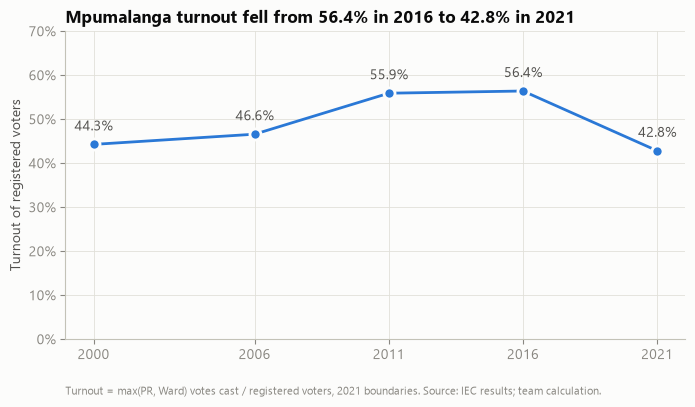

In [27]:
# =====================================================================================
# 4.3 Figure 1: Mpumalanga turnout, 2000-2021
# -------------------------------------------------------------------------------------
# WHAT:  One line: Mpumalanga's local-election turnout in each election.
# WHY:   The opening fact of our story: turnout dropped sharply in 2021.
# SAVED AS: derived/figures/fig1_mpumalanga_turnout.png
# =====================================================================================
fig, ax = plt.subplots(figsize=(8, 4))
x, y = province_turnout.index, province_turnout['turnout_pct']
ax.plot(x, y, color=SERIES_1, marker='o', markersize=8, markeredgecolor=SURFACE, markeredgewidth=2)
for xi, yi in zip(x, y):   # write the % above each point
    ax.annotate(f'{yi:.1f}%', (xi, yi), textcoords='offset points', xytext=(0, 10), ha='center', color=INK_2)
ax.set_ylim(0, 70); ax.set_xticks(ELECTIONS)      # y starts at 0 so the drop isn't exaggerated
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_title(f'Mpumalanga turnout fell from {y.loc[2016]:.1f}% in 2016 to {y.loc[2021]:.1f}% in 2021')
ax.set_ylabel('Turnout of registered voters')
ax.text(0, -0.18, 'Turnout = max(PR, Ward) votes cast / registered voters, 2021 boundaries. Source: IEC results; team calculation.',
        transform=ax.transAxes, color=MUTED, fontsize=8)
save(fig, 'fig1_mpumalanga_turnout')

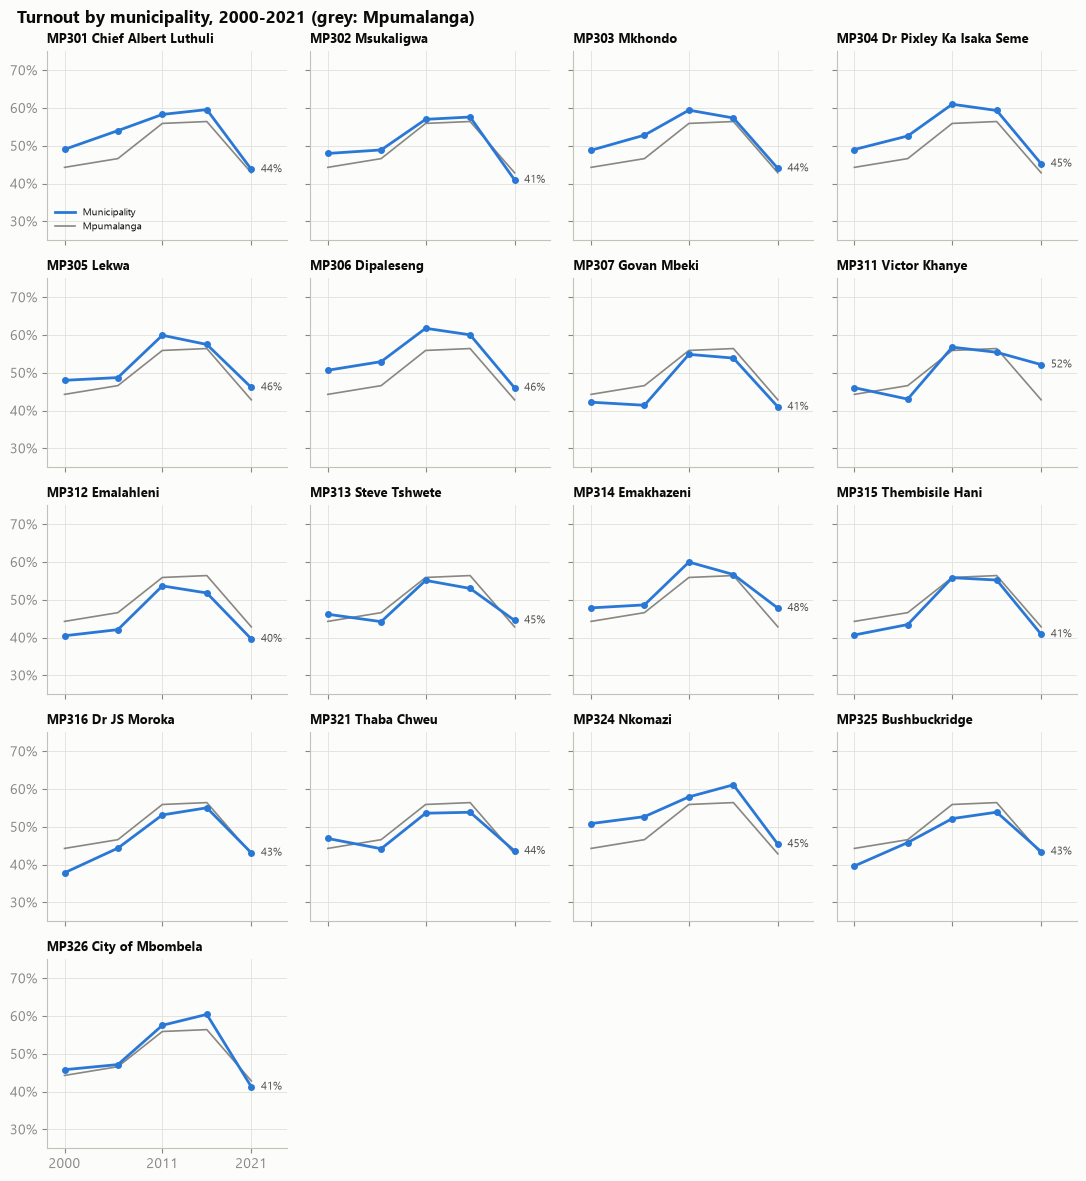

,election_year,2000,2006,2011,2016,2021
municipality_code_2021,short_name,,,,,
MP301,Chief Albert Luthuli,49.0,54.0,58.3,59.6,43.8
MP302,Msukaligwa,48.0,48.9,57.0,57.6,41.0
MP303,Mkhondo,48.8,52.8,59.4,57.3,44.0
MP304,Dr Pixley Ka Isaka Seme,49.0,52.6,61.0,59.3,45.2
MP305,Lekwa,48.0,48.7,59.9,57.5,46.1
MP306,Dipaleseng,50.7,52.9,61.8,60.0,46.0
MP307,Govan Mbeki,42.2,41.4,54.9,53.9,41.0
MP311,Victor Khanye,46.0,43.0,56.8,55.4,52.2
MP312,Emalahleni,40.5,42.1,53.7,51.8,39.6


In [28]:
# =====================================================================================
# 4.4 Figure 2: turnout by municipality (17 small charts)
# -------------------------------------------------------------------------------------
# WHAT:  One small chart per municipality. BLUE = that municipality, GREY = Mpumalanga as
#        a whole (the same grey line in every panel, as a reference).
# HOW TO READ: blue above grey = the municipality voted more than the province; below = less.
# SAVED AS: derived/figures/fig2_municipal_turnout.png (all values in the table below)
# =====================================================================================
munis = muni_turnout.sort_values('municipality_code_2021')[['municipality_code_2021', 'short_name']].drop_duplicates()
fig, axes = plt.subplots(5, 4, figsize=(11, 12), sharex=True, sharey=True)
for ax, (code_, name) in zip(axes.flat, munis.itertuples(index=False)):
    ax.plot(province_turnout.index, province_turnout['turnout_pct'], color=REFERENCE, linewidth=1.2)
    p = muni_turnout[muni_turnout.municipality_code_2021 == code_].set_index('election_year')['turnout_pct']
    ax.plot(p.index, p.values, color=SERIES_1, marker='o', markersize=4)
    ax.annotate(f'{p.iloc[-1]:.0f}%', (p.index[-1], p.iloc[-1]), textcoords='offset points', xytext=(7, 0), ha='left', va='center', color=INK_2, fontsize=8)
    ax.set_title(f'{code_} {name}', fontsize=9); ax.set_ylim(25, 75); ax.set_xlim(1998, 2025); ax.set_xticks([2000, 2011, 2021])
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
for ax in axes.flat[len(munis):]:
    ax.set_visible(False)                         # 17 municipalities, 20 slots
axes.flat[0].legend(handles=[plt.Line2D([], [], color=SERIES_1, lw=2, label='Municipality'),
                             plt.Line2D([], [], color=REFERENCE, lw=1.2, label='Mpumalanga')], loc='lower left', fontsize=7)
fig.suptitle('Turnout by municipality, 2000-2021 (grey: Mpumalanga)', x=0.02, ha='left', fontweight='bold')
fig.tight_layout()
save(fig, 'fig2_municipal_turnout')
display(muni_turnout.pivot_table(index=['municipality_code_2021', 'short_name'], columns='election_year', values='turnout_pct').round(1))

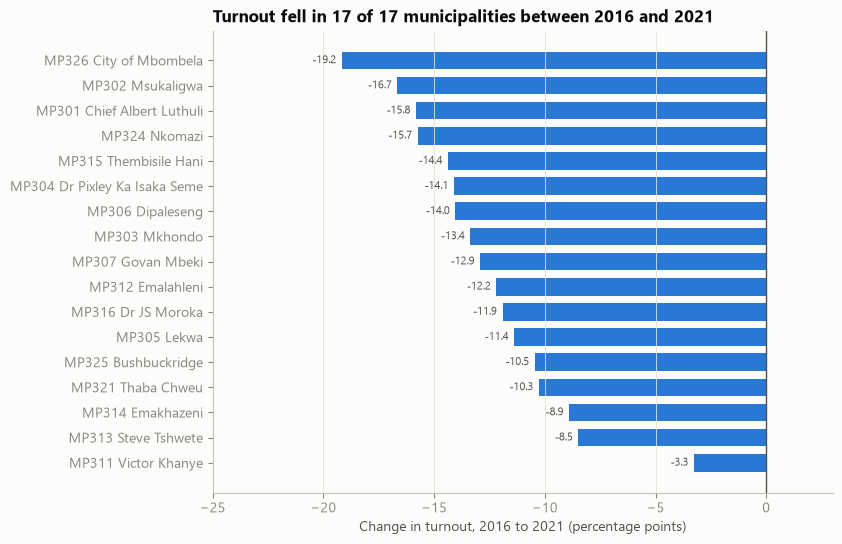

,election_year,2000,2006,2011,2016,2021,change_2016_2021_pp
municipality_code_2021,short_name,,,,,,
MP311,Victor Khanye,46.0,43.0,56.8,55.4,52.2,-3.3
MP313,Steve Tshwete,46.2,44.2,55.1,53.0,44.5,-8.5
MP314,Emakhazeni,47.9,48.6,60.0,56.7,47.8,-8.9
MP321,Thaba Chweu,46.9,44.2,53.6,53.8,43.6,-10.3
MP325,Bushbuckridge,39.6,45.8,52.2,53.9,43.4,-10.5
MP305,Lekwa,48.0,48.7,59.9,57.5,46.1,-11.4
MP316,Dr JS Moroka,37.8,44.4,53.1,55.0,43.1,-11.9
MP312,Emalahleni,40.5,42.1,53.7,51.8,39.6,-12.2
MP307,Govan Mbeki,42.2,41.4,54.9,53.9,41.0,-12.9


In [29]:
# =====================================================================================
# 4.5 Figure 3: change in turnout per municipality, 2016 -> 2021
# -------------------------------------------------------------------------------------
# WHAT:  One bar per municipality: percentage points (pp) gained or lost between 2016 and
#        2021, sorted from the biggest drop.
# WHY:   Shows where the 2021 collapse was worst.
# SAVED AS: derived/figures/fig3_turnout_change_2016_2021.png
# =====================================================================================
m = muni_turnout.pivot_table(index=['municipality_code_2021', 'short_name'], columns='election_year', values='turnout_pct')
m['change_2016_2021_pp'] = m[2021] - m[2016]
m = m.sort_values('change_2016_2021_pp', ascending=False)
labels = [f'{c} {n}' for c, n in m.index]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(labels, m['change_2016_2021_pp'], color=SERIES_1, height=0.7)
for i, v in enumerate(m['change_2016_2021_pp']):
    ax.annotate(f'{v:+.1f}', (v, i), xytext=(-4 if v < 0 else 4, 0), textcoords='offset points',
                ha='right' if v < 0 else 'left', va='center', color=INK_2, fontsize=8)
ax.axvline(0, color=INK_2, linewidth=1); ax.grid(axis='y', visible=False)
ax.set_xlim(min(-25, m['change_2016_2021_pp'].min() - 3), 3)
ax.set_xlabel('Change in turnout, 2016 to 2021 (percentage points)')
ax.set_title(f"Turnout fell in {(m['change_2016_2021_pp'] < 0).sum()} of {len(m)} municipalities between 2016 and 2021")
save(fig, 'fig3_turnout_change_2016_2021')
display(m.round(1))

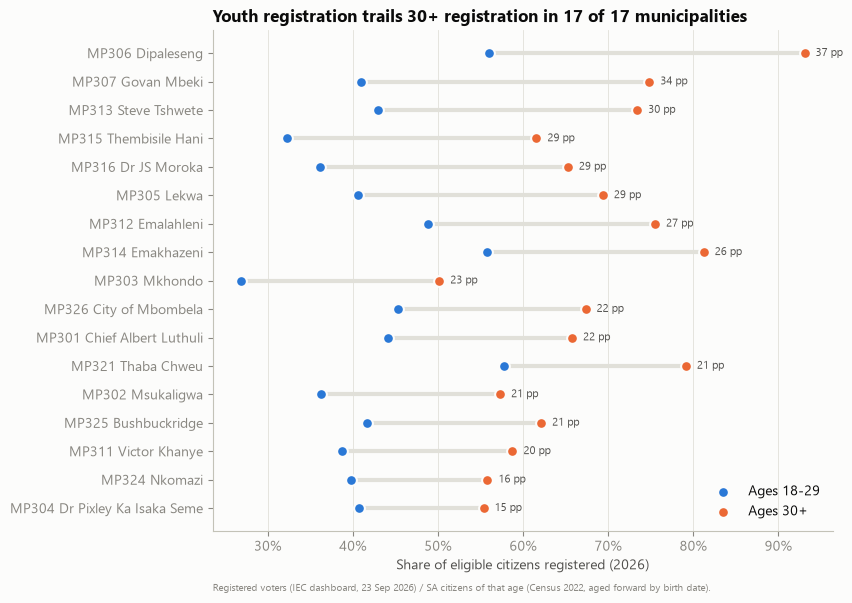

,youth_registration_rate_2026_pct,older_registration_rate_2026_pct,youth_registration_gap_pp,youth_share_of_roll_2026_pct
municipality_code,,,,
MP304,40.8,55.4,14.6,21.8
MP324,39.8,55.8,16.0,24.5
MP311,38.7,58.8,20.0,19.7
MP325,41.6,62.1,20.5,22.9
MP302,36.2,57.3,21.1,18.8
MP321,57.8,79.1,21.3,19.6
MP301,44.1,65.8,21.6,23.3
MP326,45.4,67.4,22.0,20.2
MP303,26.9,50.2,23.3,19.8


In [30]:
# =====================================================================================
# 4.6 Figure 4: 2026 registration, youth (18-29) vs 30+, per municipality
# -------------------------------------------------------------------------------------
# WHAT:  For each municipality, two dots joined by a line: the % of 18-29-year-old
#        citizens registered (blue) and the % of 30+ citizens registered (orange).
# WHY:   The YOUTH REGISTRATION GAP from our problem statement (Part B). The longer the
#        line, the bigger the gap. Sorted with the biggest gap at the top.
# SAVED AS: derived/figures/fig4_youth_vs_older_registration_2026.png
# =====================================================================================
r = registration.sort_values('youth_registration_gap_pp')
names = muni_turnout.drop_duplicates('municipality_code_2021').set_index('municipality_code_2021')['short_name']
labels = [f'{c} {names[c]}' for c in r.index]
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.hlines(labels, r['youth_registration_rate_2026_pct'], r['older_registration_rate_2026_pct'], color=GRID, linewidth=3)
ax.scatter(r['youth_registration_rate_2026_pct'], labels, s=60, color=SERIES_1, edgecolor=SURFACE, linewidth=1.5, zorder=3, label='Ages 18-29')
ax.scatter(r['older_registration_rate_2026_pct'], labels, s=60, color=SERIES_2, edgecolor=SURFACE, linewidth=1.5, zorder=3, label='Ages 30+')
for i, (c, row) in enumerate(r.iterrows()):
    ax.annotate(f"{row['youth_registration_gap_pp']:.0f} pp", (row['older_registration_rate_2026_pct'], i), xytext=(8, 0),
                textcoords='offset points', va='center', color=INK_2, fontsize=8)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0)); ax.grid(axis='y', visible=False)
ax.set_xlabel('Share of eligible citizens registered (2026)')
ax.set_title(f"Youth registration trails 30+ registration in {(r['youth_registration_gap_pp'] > 0).sum()} of {len(r)} municipalities")
ax.legend(loc='lower right')
ax.text(0, -0.12, 'Registered voters (IEC dashboard, 23 Sep 2026) / SA citizens of that age (Census 2022, aged forward by birth date).',
        transform=ax.transAxes, color=MUTED, fontsize=7)
save(fig, 'fig4_youth_vs_older_registration_2026')
display(r[['youth_registration_rate_2026_pct', 'older_registration_rate_2026_pct', 'youth_registration_gap_pp', 'youth_share_of_roll_2026_pct']].round(1))

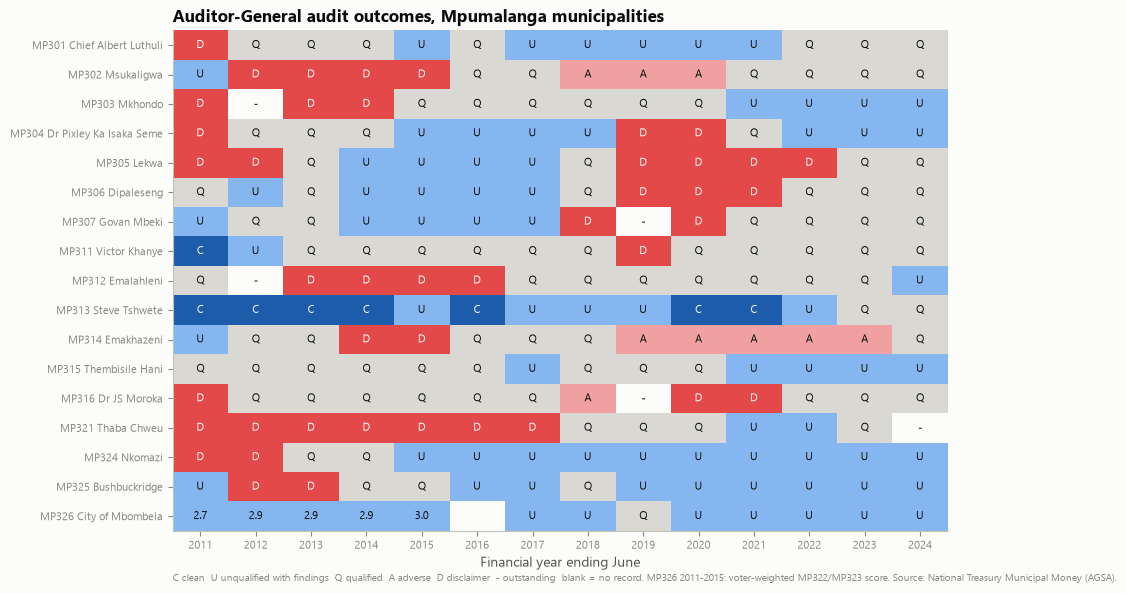

In [31]:
# =====================================================================================
# 4.7 Figure 5: municipal performance, Auditor-General audit outcomes 2011-2024
# -------------------------------------------------------------------------------------
# WHAT:  A grid: rows = municipalities, columns = financial years. Each cell shows the
#        audit opinion (C = clean, U = unqualified with findings, Q = qualified,
#        A = adverse, D = disclaimer, - = outstanding) and is coloured from red (worst)
#        to blue (best).
# WHY:   The "municipal scores (performance)" part of our plan, at a glance.
# SAVED AS: derived/figures/fig5_audit_outcomes.png
# =====================================================================================
LETTER ={4: 'C', 3: 'U', 2: 'Q', 1: 'A', 0: 'D'}
grid = audit_scores.loc[sorted(audit_scores.index)]
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.imshow(grid.to_numpy(dtype=float), cmap=ListedColormap(ORDINAL), norm=BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], 5), aspect='auto')
outstanding = audit_raw[audit_raw.outstanding].set_index(['municipality_code', 'financial_year_end']).index
for i, code_ in enumerate(grid.index):
    for j, fy in enumerate(grid.columns):
        v = grid.loc[code_, fy]
        txt = '-' if (code_, fy) in outstanding else ('' if pd.isna(v) else LETTER.get(int(round(v)), ''))
        if code_ == 'MP326' and fy <= 2015 and not pd.isna(v):
            txt = f'{v:.1f}'                          # blended MP322/MP323 score
        ax.text(j, i, txt, ha='center', va='center', fontsize=8, color=SURFACE if (not pd.isna(v) and (v <= 0.5 or v >= 3.5)) else INK)
ax.set_xticks(range(len(grid.columns)), [str(c) for c in grid.columns], rotation=0, fontsize=8)
ax.set_yticks(range(len(grid.index)), [f'{c} {names[c]}' for c in grid.index], fontsize=8)
ax.grid(False)
ax.set_xlabel('Financial year ending June')
ax.set_title('Auditor-General audit outcomes, Mpumalanga municipalities')
ax.text(0, -0.1, 'C clean  U unqualified with findings  Q qualified  A adverse  D disclaimer  - outstanding  blank = no record. '
                 'MP326 2011-2015: voter-weighted MP322/MP323 score. Source: National Treasury Municipal Money (AGSA).',
        transform=ax.transAxes, color=MUTED, fontsize=7)
save(fig, 'fig5_audit_outcomes')

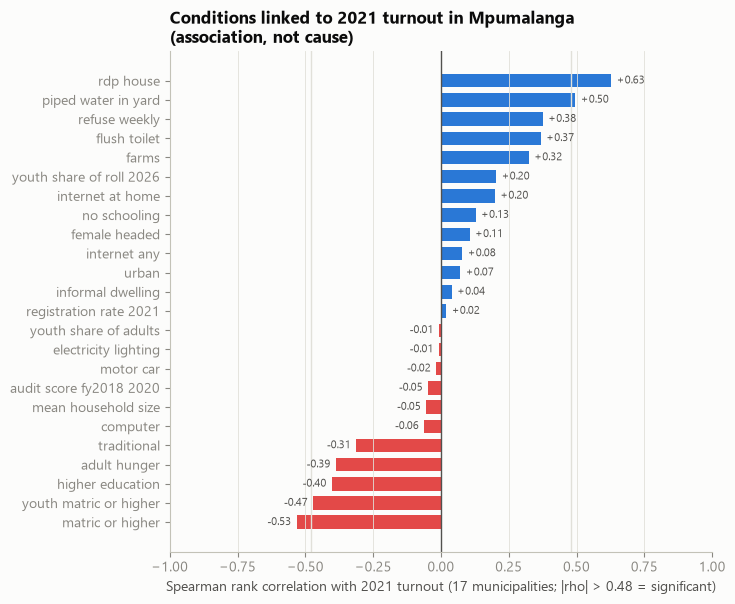

,spearman_rho
matric_or_higher_pct,-0.532
youth_matric_or_higher_pct,-0.471
higher_education_pct,-0.402
adult_hunger_pct,-0.387
traditional_pct,-0.312
computer_pct,-0.061
mean_household_size,-0.054
audit_score_fy2018_2020,-0.047
motor_car_pct,-0.017
electricity_lighting_pct,-0.007


In [32]:
# =====================================================================================
# 4.8 Figure 6: which conditions go with higher or lower 2021 turnout
# -------------------------------------------------------------------------------------
# WHAT:  For each indicator, a number between -1 and +1 (Spearman rank correlation):
#        did municipalities with MORE of it have HIGHER (+, blue) or LOWER (-, red)
#        turnout in 2021?
# CAUTION: only 17 municipalities, so these are indicative. With n = 17, a correlation
#        needs to be about +/-0.48 or more to be statistically significant (5% level).
#        This shows ASSOCIATION ONLY, not cause.
# SAVED AS: derived/figures/fig6_correlation_turnout_2021.png
# =====================================================================================
t21 = muni_turnout[muni_turnout.election_year == 2021].set_index('municipality_code_2021')['turnout_pct']
context_cols = ['internet_any_pct', 'internet_at_home_pct', 'computer_pct', 'motor_car_pct', 'piped_water_in_yard_pct',
                'electricity_lighting_pct', 'flush_toilet_pct', 'refuse_weekly_pct', 'informal_dwelling_pct', 'rdp_house_pct',
                'adult_hunger_pct', 'female_headed_pct', 'urban_pct', 'traditional_pct', 'farms_pct', 'mean_household_size',
                'matric_or_higher_pct', 'higher_education_pct', 'no_schooling_pct', 'youth_matric_or_higher_pct', 'youth_share_of_adults_pct']
audit_before_2021 = audit_scores[[2018, 2019, 2020]].mean(axis=1).rename('audit_score_fy2018_2020')
extra = registration[['registration_rate_2021_pct', 'youth_share_of_roll_2026_pct']].join(audit_before_2021)
corr = census_muni[context_cols].join(extra).corrwith(t21, method='spearman').sort_values().rename('spearman_rho').to_frame()
fig, ax = plt.subplots(figsize=(7, 6.5))
colors = [DIVERGING['positive'] if v >= 0 else DIVERGING['negative'] for v in corr['spearman_rho']]
ax.barh(corr.index.str.replace('_pct', '').str.replace('_', ' '), corr['spearman_rho'], color=colors, height=0.7)
for i, v in enumerate(corr['spearman_rho']):
    ax.annotate(f'{v:+.2f}', (v, i), xytext=(4 if v >= 0 else -4, 0), textcoords='offset points',
                ha='left' if v >= 0 else 'right', va='center', color=INK_2, fontsize=8)
for edge in (-0.48, 0.48):
    ax.axvline(edge, color=GRID, linewidth=1)
ax.axvline(0, color=INK_2, linewidth=1); ax.set_xlim(-1, 1); ax.grid(axis='y', visible=False)
ax.set_xlabel('Spearman rank correlation with 2021 turnout (17 municipalities; |rho| > 0.48 = significant)')
ax.set_title('Conditions linked to 2021 turnout in Mpumalanga\n(association, not cause)')
save(fig, 'fig6_correlation_turnout_2021')
display(corr.round(3))

### Feature engineering

One row per **voting district x target election**. Every feature must pass the leakage test: *would this value be known before the election being predicted?* Anything from the target election's own count (votes cast, spoilt votes, turnout) is excluded.

| Feature group | Built from | Known before the election? |
|---|---|---|
| Previous turnout of the voting district (1 and 2 elections back) and its change | earlier elections | yes |
| Previous turnout of its municipality and of Mpumalanga | earlier elections | yes |
| **Position relative to Mpumalanga** at the previous two elections (district and municipality) | earlier elections | yes |
| **Party competition** at the previous election: effective number of parties, winning margin, winner's share, ANC share and its change (PR ballot) | earlier elections | yes |
| Size of the district at the previous election | earlier roll | yes |
| Growth of the municipality's voters' roll since the previous election | roll certified before election day (2026: IEC dashboard, 23 Sep 2026) | yes |
| Previous spoilt-ballot rate | earlier elections | yes |
| Municipal audit score: latest financial year, and 3-year average | Auditor-General, financial years ending at least a year before the election | yes (not available before FY2011, so missing for the 2006 and 2011 targets) |
| Latest national/provincial election turnout of the municipality, and how many years before | IEC provincial-election reports 2004, 2009, 2014, 2019, 2024 | yes (only elections held before the target year) |
| Census 2022 municipal context | Census 2022 | yes for 2026; for 2006-2021 it is a later snapshot used as slow-moving context (stated limitation) |

The youth share of the roll exists only for 2026, so it is **not** a model feature. It enters Part D (priority list) instead.

In [33]:
# =====================================================================================
# 4.9 Feature table: one row per voting district x election we want to predict
# -------------------------------------------------------------------------------------
# WHAT:  For each target election (2006, 2011, 2016, 2021, and 2026 for the forecast),
#        every voting district gets FEATURES known BEFORE that election, e.g.:
#          vd_turnout_lag1      = the district's turnout at the PREVIOUS election
#          vd_rel_lag1          = the same, RELATIVE to Mpumalanga's turnout that year
#                                 (+5 = five points above the province, -5 = below)
#          muni_rel_lag1        = its municipality's previous position relative to the province
#          vd_enp_lag1          = party competition at the previous election: the "effective
#                                 number of parties" on the PR ballot (1 = one party took
#                                 every vote; 2 = two equally strong parties)
#          vd_margin_lag1       = winning party's lead over the runner-up (0-1)
#          vd_anc_share_lag1    = ANC share of the PR vote, and its change (the dominant
#                                 party's decline is the main political change of the period)
#          muni_roll_growth_pct = how much the municipality's voters' roll grew
#          c22_...              = Census 2022 conditions of the municipality
# WHY RELATIVE: turnout rises and falls across the whole province from one election to
#        the next (2016 -> 2021: -13.6 points). A district's position relative to the
#        province is far more stable, so Stage 5 forecasts the two parts separately.
# WHY PARTY COMPETITION: close contests give voters a reason to turn out; one-party areas
#        do not. Built from the PR ballot because every voter receives one.
# AUDIT TIMING: an audit for the financial year ending June Y is published around
#        Nov-Dec Y. So for an election in year T we use financial years up to T-1
#        (2026: the latest available, FY2024).
# LOOK FOR: the summary table. vd_history_pct = % of districts that also existed at the
#        previous election. New or renumbered districts fall back on municipal history.
# =====================================================================================
def lagged(frame, value_col, key_cols):
    """Wide table: one row per district (or municipality), one column per election."""
    return frame.pivot_table(index=key_cols, columns='election_year', values=value_col)

vd_t = lagged(vd_turnout, 'turnout_pct', 'voting_district')
vd_reg = lagged(vd_turnout, 'registered_voters', 'voting_district')
vd_spoilt = lagged(vd_turnout, 'spoilt_pct', 'voting_district')
mu_t = lagged(muni_turnout, 'turnout_pct', 'municipality_code_2021')
mu_reg = lagged(muni_turnout, 'registered_voters', 'municipality_code_2021')
mu_reg[2026] = registration['registered_2026']          # 2026 roll (IEC dashboard)

# --- Party competition per voting district and election (PR ballot, from results_long)
pr_votes = (results_long[results_long.ballot_type == 'PR']
            .groupby(['election_year', 'voting_district', 'party_name'])['party_valid_votes'].sum())
pr_share = (pr_votes / pr_votes.groupby(level=['election_year', 'voting_district']).transform('sum')).dropna().rename('share').reset_index()
pr_share = pr_share.sort_values(['election_year', 'voting_district', 'share'], ascending=[True, True, False])
by_vd = pr_share.groupby(['election_year', 'voting_district'])['share']
pr_share['place'] = by_vd.cumcount()                    # 0 = winner, 1 = runner-up, ...
competition = pd.DataFrame({'enp': 1 / (pr_share.assign(sq=pr_share['share'] ** 2)
                                        .groupby(['election_year', 'voting_district'])['sq'].sum()),
                            'winner_share': by_vd.max()})
runner_up = pr_share[pr_share['place'] == 1].set_index(['election_year', 'voting_district'])['share']
competition['margin'] = competition['winner_share'] - runner_up.reindex(competition.index).fillna(0)
is_anc = pr_share['party_name'].str.upper().str.startswith('AFRICAN NATIONAL CONGRESS')
competition['anc_share'] = (pr_share[is_anc].groupby(['election_year', 'voting_district'])['share'].sum()
                            .reindex(competition.index).fillna(0))
comp_wide = {c: competition[c].unstack('election_year') for c in competition.columns}   # district x election
print('Party competition, average per voting district (PR ballot):')
display(competition.groupby('election_year').mean().round(3))

TARGETS = [2006, 2011, 2016, 2021, 2026]
PREVIOUS = {2006: 2000, 2011: 2006, 2016: 2011, 2021: 2016, 2026: 2021}   # "the election before"

def audit_features(t):
    """Latest audit score and 3-year average using financial years up to t-1."""
    years = [fy for fy in audit_scores.columns if fy <= t - 1]
    if not years:
        return pd.Series(np.nan, index=audit_scores.index), pd.Series(np.nan, index=audit_scores.index)
    last = audit_scores[years].ffill(axis=1).iloc[:, -1]
    avg3 = audit_scores[years[-3:]].mean(axis=1)
    return last, avg3

def npe_features(t):
    """Most recent provincial-election turnout held BEFORE year t, per municipality, and how many years ago.
    If a municipality has no value in that year (e.g. MP325 in 2004), its latest earlier value is used."""
    years = [y for y in npe_turnout.columns if y < t]
    empty = pd.Series(np.nan, index=npe_turnout.index)
    if not years:
        return empty, empty, empty
    sub = npe_turnout[years]
    last_year = sub.notna().mul(sub.columns.to_numpy()).replace(0, np.nan).max(axis=1)
    last = sub.ffill(axis=1).iloc[:, -1]
    previous = sub.iloc[:, :-1].ffill(axis=1).iloc[:, -1] if len(years) > 1 else empty
    return last, t - last_year, last - previous      # change between the last two provincial elections

def party_lag(col, year, vd):
    """A district's party-competition value at an earlier election (NaN if it did not exist then)."""
    return vd.map(comp_wide[col][year]) if year in comp_wide[col].columns else np.nan

rows = []
for t in TARGETS:
    p1 = PREVIOUS[t]; p2 = PREVIOUS.get(p1)             # previous election, and the one before that
    base_year = t if t != 2026 else 2021                # 2026 districts = the 2021 districts
    base = vd_turnout[vd_turnout.election_year == base_year][['voting_district', 'province_2021', 'municipality_code_2021', 'municipality_name_2021']].copy()
    base['target_year'] = t
    vd = base['voting_district']; mu = base['municipality_code_2021']
    prov_p1 = province_turnout.loc[p1, 'turnout_pct']
    prov_p2 = province_turnout.loc[p2, 'turnout_pct'] if p2 else np.nan
    # --- features: all from EARLIER elections (p1, p2), the pre-election roll, or earlier audits
    base['vd_turnout_lag1'] = vd.map(vd_t[p1])
    base['vd_turnout_lag2'] = vd.map(vd_t[p2]) if p2 else np.nan
    base['vd_turnout_change_lag'] = base['vd_turnout_lag1'] - base['vd_turnout_lag2']
    base['vd_history_available'] = base['vd_turnout_lag1'].notna()
    base['vd_rel_lag1'] = base['vd_turnout_lag1'] - prov_p1          # position relative to the province
    base['vd_rel_lag2'] = base['vd_turnout_lag2'] - prov_p2
    base['vd_rel_change_lag'] = base['vd_rel_lag1'] - base['vd_rel_lag2']
    base['vd_registered_lag1_log'] = np.log1p(vd.map(vd_reg[p1]))      # district size (log scale)
    base['vd_spoilt_pct_lag1'] = vd.map(vd_spoilt[p1])
    base['vd_enp_lag1'] = party_lag('enp', p1, vd)
    base['vd_winner_share_lag1'] = party_lag('winner_share', p1, vd)
    base['vd_margin_lag1'] = party_lag('margin', p1, vd)
    base['vd_anc_share_lag1'] = party_lag('anc_share', p1, vd)
    base['vd_anc_change_lag'] = base['vd_anc_share_lag1'] - (party_lag('anc_share', p2, vd) if p2 else np.nan)
    base['muni_turnout_lag1'] = mu.map(mu_t[p1])
    base['muni_turnout_lag2'] = mu.map(mu_t[p2]) if p2 else np.nan
    base['muni_rel_lag1'] = base['muni_turnout_lag1'] - prov_p1
    base['muni_rel_lag2'] = base['muni_turnout_lag2'] - prov_p2
    base['province_turnout_lag1'] = prov_p1
    base['muni_roll_growth_pct'] = 100 * (mu.map(mu_reg[t]) / mu.map(mu_reg[p1]) - 1)
    base['years_since_previous'] = t - p1
    last, avg3 = audit_features(t)
    base['muni_audit_score_last'] = mu.map(last)
    base['muni_audit_score_3yr'] = mu.map(avg3)
    npe_last, npe_age, npe_change = npe_features(t)
    base['muni_npe_turnout_last'] = mu.map(npe_last)             # latest provincial-election turnout before t
    base['muni_npe_years_before'] = mu.map(npe_age)              # how many years before t that election was
    base['muni_npe_change_pp'] = mu.map(npe_change)              # change between the last two provincial elections
    if t != 2026:   # --- the TARGET (the answer), only for elections that have already happened
        base['turnout_pct'] = vd.map(vd_t[t])
        base['registered_voters'] = vd.map(vd_reg[t])
    rows.append(base)
features_vd = pd.concat(rows, ignore_index=True)

census_features = census_muni[context_cols].add_prefix('c22_')
features_vd = features_vd.merge(census_features, left_on='municipality_code_2021', right_index=True, how='left')

summary = features_vd.groupby('target_year').agg(rows=('voting_district', 'size'),
                                                 vd_history_pct=('vd_history_available', 'mean'),
                                                 party_history_pct=('vd_enp_lag1', lambda s: s.notna().mean()),
                                                 audit_available_pct=('muni_audit_score_last', lambda s: s.notna().mean()),
                                                 target_available=('turnout_pct', lambda s: s.notna().mean()))
pct_cols = ['vd_history_pct', 'party_history_pct', 'audit_available_pct']
summary[pct_cols] = (100 * summary[pct_cols]).round(1)
display(summary)

Party competition, average per voting district (PR ballot):


,enp,winner_share,margin,anc_share
election_year,,,,
2000,1.580,0.782,0.620,0.605
2006,1.578,0.795,0.658,0.684
2011,1.389,0.848,0.742,0.806
2016,1.630,0.774,0.629,0.732
2021,2.045,0.675,0.475,0.637


,rows,vd_history_pct,party_history_pct,audit_available_pct,target_available
target_year,,,,,
2006,1254,76.6,76.3,0.0,1.0
2011,1565,79.8,79.8,0.0,1.0
2016,1744,89.2,89.2,100.0,1.0
2021,1785,97.2,97.2,100.0,1.0
2026,1785,100.0,100.0,100.0,0.0


In [34]:
# =====================================================================================
# 4.10 Leakage check, feature sets and feature dictionary
# -------------------------------------------------------------------------------------
# WHAT:  Automatic tests proving no feature contains the answer, the feature sets used in
#        Stage 5, and a table describing every feature (source, known before the
#        election?, % missing).
# WHY:   "Leakage" = using information from the election you are predicting. It makes a
#        model look brilliant in testing and useless in reality. Judges look for this.
# TESTS: (1) no outcome column (votes, turnout...) is a feature;
#        (2) for 2021 rows, "previous turnout" equals the 2016 value, NOT the 2021 value;
#        (3) audit features for 2021 use financial years <= 2020 only;
#        (4) provincial-election features come from an election BEFORE the target year;
#        (5) party competition for 2021 rows comes from the 2016 PR ballot;
#        (6) relative position for 2021 rows = 2016 turnout minus 2016 PROVINCE turnout.
#        If a test fails, the cell stops with an error.
# FEATURE SETS (Stage 5):
#        LOCAL_FEATURES   = district turnout history (relative to the province), district
#                           size, spoilt ballots and party competition
#        CONTEXT_FEATURES = municipal context: Census 2022, audit record, provincial-election
#                           turnout, roll growth (tested in Stage 5: do they add anything?)
#        V1_FEATURES      = the first version's one-step model (kept for comparison)
# =====================================================================================
FEATURES = [c for c in features_vd.columns if c.startswith(('vd_', 'muni_', 'province_turnout', 'years_', 'c22_')) and c != 'vd_history_available']
TARGET = 'turnout_pct'
forbidden = {'turnout_votes', 'votes_cast', 'spoilt_votes', 'turnout_pct', 'registered_voters'}
assert not forbidden & set(FEATURES), 'a same-election outcome leaked into the features'

LOCAL_FEATURES = ['vd_rel_lag1', 'vd_rel_lag2', 'vd_rel_change_lag', 'muni_rel_lag1', 'muni_rel_lag2',
                  'vd_registered_lag1_log', 'vd_spoilt_pct_lag1',
                  'vd_enp_lag1', 'vd_winner_share_lag1', 'vd_margin_lag1', 'vd_anc_share_lag1', 'vd_anc_change_lag']
CONTEXT_FEATURES = ['muni_roll_growth_pct', 'muni_audit_score_last', 'muni_audit_score_3yr', 'muni_npe_turnout_last',
                    'muni_npe_change_pp'] + [c for c in FEATURES if c.startswith('c22_')]
NEW_IN_V2 = ('vd_rel', 'muni_rel', 'vd_enp', 'vd_winner', 'vd_margin', 'vd_anc')
V1_FEATURES = [c for c in FEATURES if not c.startswith(NEW_IN_V2) and c != 'muni_npe_years_before']
assert set(LOCAL_FEATURES + CONTEXT_FEATURES) <= set(FEATURES)

chk = features_vd[(features_vd.target_year == 2021) & features_vd.vd_turnout_lag1.notna()]
assert np.allclose(chk['vd_turnout_lag1'], chk['voting_district'].map(vd_t[2016]))
assert not np.allclose(chk['vd_turnout_lag1'], chk['turnout_pct'])
a21 = features_vd[features_vd.target_year == 2021].drop_duplicates('municipality_code_2021').set_index('municipality_code_2021')['muni_audit_score_last']
assert np.allclose(a21, audit_scores.loc[a21.index, [fy for fy in audit_scores.columns if fy <= 2020]].ffill(axis=1).iloc[:, -1], equal_nan=True)
assert (features_vd['muni_npe_years_before'].dropna() > 0).all(), 'a provincial election in or after the target year leaked in'
p21 = features_vd[(features_vd.target_year == 2021) & features_vd.vd_enp_lag1.notna()]
assert np.allclose(p21['vd_enp_lag1'], p21['voting_district'].map(comp_wide['enp'][2016])), 'party competition not from the previous election'
assert np.allclose(chk['vd_rel_lag1'], chk['vd_turnout_lag1'] - province_turnout.loc[2016, 'turnout_pct'])

feature_dictionary = pd.DataFrame({'feature': FEATURES})
feature_dictionary['source'] = np.select(
    [feature_dictionary.feature.str.startswith('c22_'), feature_dictionary.feature.eq('muni_roll_growth_pct'),
     feature_dictionary.feature.str.startswith('muni_audit'), feature_dictionary.feature.str.startswith('muni_npe'),
     feature_dictionary.feature.str.startswith(('vd_enp', 'vd_winner', 'vd_margin', 'vd_anc'))],
    ['Census 2022 (Stage 3)', 'IEC voters roll (Stage 2; 2026: IEC dashboard)', 'Auditor-General via Municipal Money (Stage 3)',
     'IEC provincial-election turnout reports (Stage 2, cell 2.8)', 'IEC results, PR-ballot party votes at the previous election (Stage 2)'],
    'IEC results, earlier elections (Stage 2)')
feature_dictionary['known_before_election'] = np.select(
    [feature_dictionary.feature.str.startswith('c22_'), feature_dictionary.feature.str.startswith('muni_audit')],
    ['yes for 2026; later snapshot for 2006-2021', 'yes (financial years up to the year before the election)'], 'yes')
feature_dictionary['model_set'] = np.select(
    [feature_dictionary.feature.isin(LOCAL_FEATURES), feature_dictionary.feature.isin(CONTEXT_FEATURES)],
    ['local position model', 'municipal context (tested)'], 'first version only')
feature_dictionary['missing_pct'] = [round(100 * features_vd.loc[features_vd.target_year < 2026, f].isna().mean(), 1) for f in FEATURES]
display(feature_dictionary)
print(f'{len(FEATURES)} features passed the leakage checks '
      f'({len(LOCAL_FEATURES)} local, {len(CONTEXT_FEATURES)} municipal context, {len(V1_FEATURES)} in the first version).')

,feature,source,known_before_election,model_set,missing_pct
0,vd_turnout_lag1,"IEC results, earlier elections (Stage 2)",yes,first version only,13.4
1,vd_turnout_lag2,"IEC results, earlier elections (Stage 2)",yes,first version only,40.9
2,vd_turnout_change_lag,"IEC results, earlier elections (Stage 2)",yes,first version only,40.9
3,vd_rel_lag1,"IEC results, earlier elections (Stage 2)",yes,local position model,13.4
4,vd_rel_lag2,"IEC results, earlier elections (Stage 2)",yes,local position model,40.9
5,vd_rel_change_lag,"IEC results, earlier elections (Stage 2)",yes,local position model,40.9
6,vd_registered_lag1_log,"IEC results, earlier elections (Stage 2)",yes,local position model,13.4
7,vd_spoilt_pct_lag1,"IEC results, earlier elections (Stage 2)",yes,local position model,13.4
8,vd_enp_lag1,"IEC results, PR-ballot party votes at the prev...",yes,local position model,13.4
9,vd_winner_share_lag1,"IEC results, PR-ballot party votes at the prev...",yes,local position model,13.4


46 features passed the leakage checks (12 local, 26 municipal context, 35 in the first version).


In [35]:
# =====================================================================================
# 4.11 Municipality table (for Parts B, C and D) and save everything
# -------------------------------------------------------------------------------------
# WHAT:  One row per municipality: turnout 2000-2021, registration rates 2021/2026, the
#        youth gap, youth share of the roll, audit scores and Census context. Also
#        PARTICIPATION = registration rate x turnout = share of ALL eligible citizens
#        who actually voted in 2021.
# SAVES: derived/features_vd.parquet, derived/features_municipality.csv,
#        derived/feature_dictionary.csv
# =====================================================================================
muni_features = (muni_turnout.pivot_table(index=['province_2021', 'municipality_code_2021', 'municipality_name_2021'],
                                          columns='election_year', values='turnout_pct')
                 .add_prefix('turnout_').reset_index().set_index('municipality_code_2021'))
muni_features['turnout_change_2016_2021_pp'] = muni_features['turnout_2021'] - muni_features['turnout_2016']
latest_fy = max(audit_scores.columns)
muni_features['audit_score_latest'] = audit_scores.ffill(axis=1)[latest_fy]
muni_features['audit_score_avg_last3'] = audit_scores[sorted(audit_scores.columns)[-3:]].mean(axis=1)
muni_features = (muni_features.join(registration[['registration_rate_2021_pct', 'registration_rate_2026_pct',
                                                  'youth_registration_rate_2026_pct', 'older_registration_rate_2026_pct',
                                                  'youth_registration_gap_pp', 'youth_share_of_roll_2026_pct',
                                                  'roll_growth_2021_2026_pct', 'registered_2026', 'eligible_18plus_2026']])
                             .join(census_features))
muni_features['participation_2021_pct'] = muni_features['registration_rate_2021_pct'] * muni_features['turnout_2021'] / 100

features_vd.to_parquet(DERIVED_DIR / 'features_vd.parquet', index=False)
muni_features.round(3).to_csv(DERIVED_DIR / 'features_municipality.csv')
feature_dictionary.to_csv(DERIVED_DIR / 'feature_dictionary.csv', index=False)
for f in ['features_vd.parquet', 'features_municipality.csv', 'feature_dictionary.csv']:
    print(f'{f:30s} {(DERIVED_DIR / f).stat().st_size:>10,} bytes')
print('Figures:', sorted(p.name for p in FIG_DIR.glob('*.png')))
print('Stage 4 complete.')

features_vd.parquet               916,667 bytes
features_municipality.csv           6,039 bytes
feature_dictionary.csv              5,200 bytes
Figures: ['fig1_mpumalanga_turnout.png', 'fig2_municipal_turnout.png', 'fig3_turnout_change_2016_2021.png', 'fig4_youth_vs_older_registration_2026.png', 'fig5_audit_outcomes.png', 'fig6_correlation_turnout_2021.png']
Stage 4 complete.


## Stage 5: Models

Each part answers one piece of the problem statement:

| Part | Question | Method |
|---|---|---|
| **A** | Which areas are most at risk of low turnout in 2026? | **Two-step turnout forecast.** Step 1: the province-wide level, i.e. how Mpumalanga as a whole will turn out, from the link between local and provincial elections. Step 2: each voting district's **local position** above or below the province, from machine learning on district history and party competition. Backtested on **2011, 2016 and 2021**. |
| **B** | Is low participation mainly a registration problem or a turnout problem? | Of every 100 eligible citizens: how many are not registered, how many registered but didn't vote, how many voted. |
| **C** | Which socio-economic factors go with low participation? | Rank correlations of Census 2022 living conditions, education and audit record with turnout, registration and the youth gap, plus a test of whether they improve the forecast. |
| **D** | Where do low turnout, a large youth gap and weak municipal performance overlap? | Participation profiles (k-means clustering, stability-checked) and a transparent priority score with the weights on show. |

**Why two steps?** The first version predicted each district's turnout directly. In the 2021 backtest every method, including that model, predicted 9-13 points too high, because turnout fell across the whole province (56.4% to 42.8%). No local feature can see a province-wide shock coming, but *where* turnout is lowest changes much less. Splitting the forecast means:
- the **map of local positions** (which areas are at risk) is learned from 1,800 voting districts and tested honestly;
- the **province-wide level**, the hard part, is forecast separately from provincial-election turnout and shown with a range, so its uncertainty is visible rather than hidden inside every district.

**Honest-evaluation rules:** models are always tested on an election they have not seen. Simple rules are the bar to beat. Results are reported at voting-district and municipality level, with the error range shown next to every forecast.

In [36]:
# =====================================================================================
# 5.1 Part A setup: the two-step forecast, candidate models and scoring
# -------------------------------------------------------------------------------------
# WHAT:  Turnout of a district = PROVINCE-WIDE LEVEL + the district's LOCAL POSITION.
#          e.g. 2021: Mpumalanga 42.8%; a district at 38.8% has local position -4.0.
# STEP 1 (province-wide level), two candidates:
#          "Same as last election"      = Mpumalanga's previous local-election turnout
#          "Provincial-election ratio"  = latest provincial-election turnout x the average
#             ratio (local turnout / preceding provincial turnout) of earlier elections.
#             Local turnout has always been well below provincial turnout; the ratio
#             carries the most recent national mood into the local-election forecast.
# STEP 2 (local position per voting district), candidates:
#          "Same position as last election" = the district's previous local position
#          "Regression to the mean"   = previous position x a factor fitted on the training
#             elections (positions drift back towards the province average)
#          Ridge regression, Gradient boosting = machine learning on LOCAL_FEATURES
#          "Gradient boosting + municipal context" = adds Census 2022, audit record,
#             provincial-election turnout and roll growth (does context help?)
#          "Ensemble" = average of gradient boosting and regression to the mean
# WEIGHTS: each district counts by its registered voters, so big districts matter more.
# SCORES:  MAE = mean absolute error in percentage points (pp); rank rho = how well the
#          ORDER is predicted (1 = perfect); bottom-20% found = of the districts that
#          really were in the lowest fifth, the % the model also placed there.
# =====================================================================================
require('features_vd', 'FEATURES', 'LOCAL_FEATURES', 'CONTEXT_FEATURES', 'V1_FEATURES', 'TARGET', 'muni_features', 'npe_muni', stage='Stage 4')

LGE_TURNOUT = province_turnout['turnout_pct']                     # Mpumalanga local-election turnout by year
LOCAL_TARGET = 'local_position'
history = features_vd[(features_vd.target_year < 2026) & features_vd[TARGET].notna() & (features_vd['registered_voters'] > 0)].copy()
history[LOCAL_TARGET] = history[TARGET] - history['target_year'].map(LGE_TURNOUT)
print(f"Training history: {len(history):,} voting district x election rows "
      f"({history.groupby('target_year').size().to_dict()})")

# ---- Step 1: province-wide level ------------------------------------------------------
npe_province = npe_muni.groupby('year')[['reg', 'votes']].sum()
NPE_TURNOUT = 100 * npe_province['votes'] / npe_province['reg']   # Mpumalanga provincial-election turnout

def npe_before(t):
    """The latest provincial election held before year t."""
    years = [y for y in NPE_TURNOUT.index if y < t]
    return max(years) if years else None

def local_to_npe_ratios(before):
    """Local turnout / preceding provincial turnout, for every local election before `before`."""
    return pd.Series({y: LGE_TURNOUT[y] / NPE_TURNOUT[npe_before(y)]
                      for y in LGE_TURNOUT.index if y < before and npe_before(y) is not None}, dtype=float)

def province_level(t, method):
    """Forecast Mpumalanga's local-election turnout in year t using only earlier elections."""
    if method == 'Same as last election':
        return LGE_TURNOUT[PREVIOUS[t]]
    return local_to_npe_ratios(t).mean() * NPE_TURNOUT[npe_before(t)]

PROVINCE_METHODS = ['Same as last election', 'Provincial-election ratio']
ratio_table = pd.DataFrame({'local_turnout': LGE_TURNOUT})
ratio_table['preceding_provincial_election'] = [npe_before(y) for y in ratio_table.index]
ratio_table['provincial_turnout'] = ratio_table['preceding_provincial_election'].map(NPE_TURNOUT)
ratio_table['ratio'] = ratio_table['local_turnout'] / ratio_table['provincial_turnout']
print('Local vs preceding provincial-election turnout, Mpumalanga:')
display(ratio_table.round(3))

# ---- Step 2: local position -------------------------------------------------------------
def gradient_boosting():
    return HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=250, min_samples_leaf=40,
                                         l2_regularization=1.0, random_state=RANDOM_SEED)

def make_local_models():
    """Fresh, untrained machine-learning candidates, each with its feature set."""
    return {
        'Ridge regression': (make_pipeline(SimpleImputer(strategy='median', add_indicator=True), StandardScaler(), Ridge(alpha=30.0)), LOCAL_FEATURES),
        'Gradient boosting': (gradient_boosting(), LOCAL_FEATURES),
        'Gradient boosting + municipal context': (gradient_boosting(), LOCAL_FEATURES + CONTEXT_FEATURES),
    }

def fit_model(model, frame, features, target):
    """Train, weighting each district by its registered voters. Only features that have
    values (and vary) in THIS training data are used, e.g. audit scores start in 2011."""
    cols = [f for f in features if frame[f].notna().any() and frame[f].nunique() > 1]
    w = frame['registered_voters'].to_numpy()
    if hasattr(model, 'named_steps'):          # the ridge pipeline
        model.fit(frame[cols], frame[target], ridge__sample_weight=w)
    else:
        model.fit(frame[cols], frame[target], sample_weight=w)
    model.used_features_ = cols
    return model

def same_position(frame):
    """Rule: the district's previous local position (its municipality's if the district is new)."""
    return frame['vd_rel_lag1'].fillna(frame['muni_rel_lag1']).fillna(0)

def fit_shrink(frame):
    """Regression to the mean: the factor b in  position = b x previous position, fitted
    (weighted least squares) on the training elections only."""
    x, y, w = same_position(frame), frame[LOCAL_TARGET], frame['registered_voters']
    return float((w * x * y).sum() / (w * x * x).sum())

def to_municipality(frame, pred_col, actual_col):
    """Registered-voter-weighted average of districts per municipality."""
    w = frame['registered_voters']
    g = frame.assign(p=frame[pred_col] * w, a=frame[actual_col] * w, w=w).groupby('municipality_code_2021')[['p', 'a', 'w']].sum()
    return pd.DataFrame({'predicted': g['p'] / g['w'], 'actual': g['a'] / g['w']})

def score(frame, pred_col, actual_col):
    """Errors and ranking quality at voting-district and municipality level."""
    m = to_municipality(frame, pred_col, actual_col)
    err = m['predicted'] - m['actual']
    worst = frame[actual_col] <= frame[actual_col].quantile(0.2)
    flagged = frame[pred_col] <= frame[pred_col].quantile(0.2)
    return {'vd_MAE_pp': np.average((frame[pred_col] - frame[actual_col]).abs(), weights=frame['registered_voters']),
            'vd_rank_rho': frame[pred_col].corr(frame[actual_col], method='spearman'),
            'bottom20_found_pct': 100 * (worst & flagged).sum() / worst.sum(),
            'muni_MAE_pp': err.abs().mean(), 'muni_bias_pp': err.mean(),
            'muni_rank_rho': m['predicted'].corr(m['actual'], method='spearman'),
            'lowest5_found': len(set(m['actual'].nsmallest(5).index) & set(m['predicted'].nsmallest(5).index))}

Training history: 6,348 voting district x election rows ({2006: 1254, 2011: 1565, 2016: 1744, 2021: 1785})
Local vs preceding provincial-election turnout, Mpumalanga:


,local_turnout,preceding_provincial_election,provincial_turnout,ratio
election_year,,,,
2000,44.278,NaN,NaN,NaN
2006,46.596,2004.0,78.577,0.593
2011,55.912,2009.0,77.611,0.720
2016,56.412,2014.0,72.801,0.775
2021,42.831,2019.0,63.201,0.678


In [37]:
# =====================================================================================
# 5.2 Part A backtest: predict 2011, 2016 and 2021 using only earlier elections
# -------------------------------------------------------------------------------------
# WHAT:  Fold 1 trains on 2006 and predicts 2011; fold 2 trains on 2006+2011 and predicts
#        2016; fold 3 trains on 2006-2016 and predicts 2021. Both steps are scored:
#          step 1 (province level): error of each method, in points;
#          step 2 (local position): every candidate, at district and municipality level.
# CHOICE RULES (decided before looking at the results):
#          step 1: the method with the lower average error;
#          step 2: the candidate with the lowest municipal error that ALSO beats both
#                  simple rules at voting-district level. If none does, the better rule.
# LOOK FOR: the province-level errors (large) against the local-position errors (small).
# =====================================================================================
FOLDS = {2011: [2006], 2016: [2006, 2011], 2021: [2006, 2011, 2016]}
RULES = ['Same position as last election', 'Regression to the mean']
LOCAL_NAMES = RULES + ['Ridge regression', 'Gradient boosting', 'Gradient boosting + municipal context', 'Ensemble']
local_rows, province_rows, backtest_preds = [], [], []
for test_year, train_years in FOLDS.items():
    train = history[history.target_year.isin(train_years)]
    test = history[history.target_year == test_year].copy()
    test['pred_Same position as last election'] = same_position(test)
    test['pred_Regression to the mean'] = fit_shrink(train) * same_position(test)
    for name, (model, feats) in make_local_models().items():
        fit_model(model, train, feats, LOCAL_TARGET)
        test[f'pred_{name}'] = model.predict(test[model.used_features_])
    test['pred_Ensemble'] = (test['pred_Gradient boosting'] + test['pred_Regression to the mean']) / 2
    for name in LOCAL_NAMES:
        local_rows.append({'test_year': test_year, 'model': name, **score(test, f'pred_{name}', LOCAL_TARGET)})
    for method in PROVINCE_METHODS:
        province_rows.append({'test_year': test_year, 'method': method, 'predicted': province_level(test_year, method),
                              'actual': LGE_TURNOUT[test_year]})
    backtest_preds.append(test)

province_backtest = pd.DataFrame(province_rows).assign(error_pp=lambda d: d['predicted'] - d['actual'])
print('STEP 1 - province-wide level (predicted - actual, points):')
display(province_backtest.pivot(index='method', columns='test_year', values='error_pp').assign(
    mean_abs_error=lambda d: d.abs().mean(axis=1)).round(1))
PROVINCE_METHOD = province_backtest.assign(abs_err=province_backtest['error_pp'].abs()).groupby('method')['abs_err'].mean().idxmin()

local_backtest = pd.DataFrame(local_rows)
local_summary = local_backtest.groupby('model')[['vd_MAE_pp', 'vd_rank_rho', 'bottom20_found_pct', 'muni_MAE_pp', 'muni_rank_rho', 'lowest5_found']].mean().loc[LOCAL_NAMES]
print('STEP 2 - local position, per backtest:')
display(local_backtest.pivot(index='model', columns='test_year', values=['vd_MAE_pp', 'muni_MAE_pp']).loc[LOCAL_NAMES].round(2))
print('STEP 2 - average over the three backtests:')
display(local_summary.round(2))

best_rule_vd = local_summary.loc[RULES, 'vd_MAE_pp'].min()
eligible = local_summary.drop(index=RULES)
eligible = eligible[eligible['vd_MAE_pp'] < best_rule_vd]
LOCAL_MODEL = eligible['muni_MAE_pp'].idxmin() if len(eligible) else local_summary.loc[RULES, 'muni_MAE_pp'].idxmin()
print(f'Chosen: step 1 = {PROVINCE_METHOD}; step 2 = {LOCAL_MODEL}')

STEP 1 - province-wide level (predicted - actual, points):


test_year,2011,2016,2021,mean_abs_error
method,,,,
Provincial-election ratio,-9.9,-8.6,1.2,6.6
Same as last election,-9.3,-0.5,13.6,7.8


STEP 2 - local position, per backtest:


vd_MAE_pp             muni_MAE_pp            
test_year                                  2011  2016  2021        2011  2016  2021
model                                                                              
Same position as last election             8.19  6.45  6.31        2.68  2.85  2.75
Regression to the mean                     6.10  5.77  5.61        1.56  1.88  2.24
Ridge regression                           5.90  5.08  5.30        1.96  1.31  2.65
Gradient boosting                          5.91  4.86  5.41        2.33  1.32  2.80
Gradient boosting + municipal context      6.13  5.10  5.05        2.79  1.51  2.57
Ensemble                                   5.54  5.01  5.33        1.60  1.48  2.50

STEP 2 - average over the three backtests:


,vd_MAE_pp,vd_rank_rho,bottom20_found_pct,muni_MAE_pp,muni_rank_rho,lowest5_found
model,,,,,,
Same position as last election,6.98,0.55,59.95,2.76,0.62,3.00
Regression to the mean,5.83,0.55,59.95,1.90,0.62,3.00
Ridge regression,5.43,0.68,55.18,1.97,0.64,2.67
Gradient boosting,5.39,0.69,58.64,2.15,0.61,2.67
Gradient boosting + municipal context,5.43,0.70,57.77,2.29,0.63,2.67
Ensemble,5.29,0.69,60.36,1.86,0.63,3.00


Chosen: step 1 = Provincial-election ratio; step 2 = Ensemble


test_year,2011,2016,2021
approach,,,
Same as last election,7.44,2.55,13.02
One-step model (first version),8.42,1.57,11.72
Two-step forecast,9.72,8.05,2.37


Average over the three backtests (actual turnout):


,muni_MAE_pp,muni_bias_pp,muni_rank_rho,lowest5_found,vd_MAE_pp,bottom20_found_pct
approach,,,,,,
Same as last election,7.67,2.50,0.62,3.0,10.58,59.95
One-step model (first version),7.24,1.32,0.59,3.0,9.35,57.32
Two-step forecast,6.71,-5.88,0.63,3.0,8.25,60.36


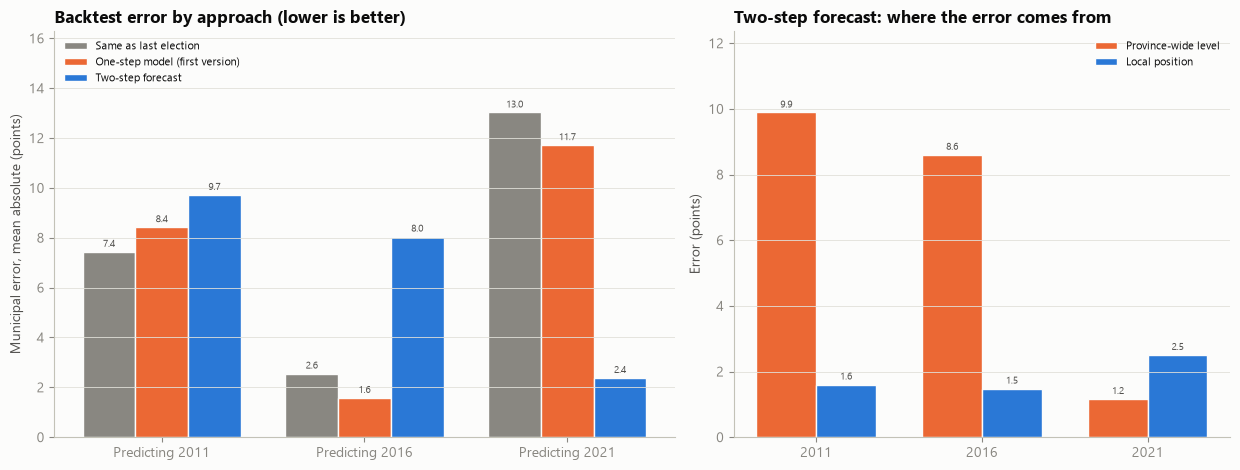

In [38]:
# =====================================================================================
# 5.3 Full comparison with the first version, and Figure 7
# -------------------------------------------------------------------------------------
# WHAT:  Puts the two steps back together (turnout = province level + local position) and
#        compares actual turnout forecasts from three approaches in the same backtests:
#          "Same as last election"            = each district's previous turnout
#          "One-step model (first version)"   = gradient boosting predicting turnout directly
#          "Two-step forecast"                = the chosen step 1 + step 2
#        Figure 7 left: municipal error of each approach, per backtest.
#        Figure 7 right: the two-step error split into its two sources.
# HOW TO READ (right): a tall orange bar and a short blue bar = the miss came from the
#        province-wide level, not from getting the local picture wrong.
# SAVED AS: derived/figures/fig7_backtest.png
# =====================================================================================
APPROACHES = ['Same as last election', 'One-step model (first version)', 'Two-step forecast']
comparison_rows = []
for test_year, test in zip(FOLDS, backtest_preds):
    train = history[history.target_year.isin(FOLDS[test_year])]
    test['abs_Same as last election'] = test['vd_turnout_lag1'].fillna(test['muni_turnout_lag1'])
    v1 = fit_model(gradient_boosting(), train, V1_FEATURES, TARGET)
    test['abs_One-step model (first version)'] = np.clip(v1.predict(test[v1.used_features_]), 0, 100)
    test['abs_Two-step forecast'] = np.clip(province_level(test_year, PROVINCE_METHOD) + test[f'pred_{LOCAL_MODEL}'], 0, 100)
    for name in APPROACHES:
        comparison_rows.append({'test_year': test_year, 'approach': name, **score(test, f'abs_{name}', TARGET)})
backtest = pd.DataFrame(comparison_rows)
backtest_summary = backtest.groupby('approach')[['muni_MAE_pp', 'muni_bias_pp', 'muni_rank_rho', 'lowest5_found', 'vd_MAE_pp', 'bottom20_found_pct']].mean().loc[APPROACHES]
display(backtest.pivot(index='approach', columns='test_year', values='muni_MAE_pp').loc[APPROACHES].round(2))
print('Average over the three backtests (actual turnout):')
display(backtest_summary.round(2))

split = pd.DataFrame({
    'Province-wide level': province_backtest[province_backtest.method == PROVINCE_METHOD].set_index('test_year')['error_pp'].abs(),
    'Local position': local_backtest[local_backtest.model == LOCAL_MODEL].set_index('test_year')['muni_MAE_pp']})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8), gridspec_kw={'width_ratios': [1.25, 1]})
pv = backtest.pivot(index='test_year', columns='approach', values='muni_MAE_pp')[APPROACHES]
x = np.arange(len(pv)); width = 0.26
for k, (name, colour) in enumerate(zip(APPROACHES, [REFERENCE, SERIES_2, SERIES_1])):
    bars = ax1.bar(x + (k - 1) * width, pv[name], width=width, color=colour, edgecolor=SURFACE, linewidth=1, label=name)
    ax1.bar_label(bars, fmt='%.1f', fontsize=7.5, color=INK_2, padding=2)
ax1.set_xticks(x, [f'Predicting {y}' for y in pv.index]); ax1.grid(axis='x', visible=False)
ax1.set_ylabel('Municipal error, mean absolute (points)'); ax1.legend(loc='upper left', fontsize=8)
ax1.set_ylim(0, pv.to_numpy().max() * 1.25)
ax1.set_title('Backtest error by approach (lower is better)')
for k, (name, colour) in enumerate(zip(split.columns, [SERIES_2, SERIES_1])):
    bars = ax2.bar(x + (k - 0.5) * 0.36, split[name], width=0.36, color=colour, edgecolor=SURFACE, linewidth=1, label=name)
    ax2.bar_label(bars, fmt='%.1f', fontsize=7.5, color=INK_2, padding=2)
ax2.set_xticks(x, [str(y) for y in split.index]); ax2.grid(axis='x', visible=False)
ax2.set_ylabel('Error (points)'); ax2.legend(loc='upper right', fontsize=8)
ax2.set_ylim(0, split.to_numpy().max() * 1.25)
ax2.set_title('Two-step forecast: where the error comes from')
fig.tight_layout()
save(fig, 'fig7_backtest')

In [39]:
# =====================================================================================
# 5.4 Part A: forecast 2026 (province-wide level + local position)
# -------------------------------------------------------------------------------------
# WHAT:  Step 2 is re-trained on every election 2006-2021 and predicts the local position
#        of each of the 2021 voting districts in 2026. Step 1 gives Mpumalanga's level.
#        Turnout forecast = province level + local position.
# PROVINCE LEVEL: central = the chosen step-1 method. The range uses the weakest and the
#        strongest local/provincial ratio seen in past elections, applied to 2024
#        provincial turnout: "if 2026 is like the worst / best past local election".
# RANGES: local position: 80% range from the backtest errors (10th-90th percentile of
#        municipal errors, three backtests). Turnout: province range + local 80% range.
# AT-RISK DISTRICTS: the fifth of voting districts with the lowest predicted local position.
# WHAT DRIVES IT: permutation importance on the 2021 backtest = how much worse the local
#        model gets when a feature's values are shuffled (bigger = more important).
# =====================================================================================
future = features_vd[features_vd.target_year == 2026].copy()
future['registered_voters'] = future['voting_district'].map(vd_reg[2021])      # 2021 district size as the weight
shrink_all = fit_shrink(history)
gb_final = fit_model(gradient_boosting(), history, LOCAL_FEATURES, LOCAL_TARGET)
local_2026 = {'Same position as last election': same_position(future),
              'Regression to the mean': shrink_all * same_position(future),
              'Gradient boosting': gb_final.predict(future[gb_final.used_features_])}
local_2026['Ensemble'] = (local_2026['Gradient boosting'] + local_2026['Regression to the mean']) / 2
if LOCAL_MODEL in local_2026:
    future['local_position_forecast'] = np.asarray(local_2026[LOCAL_MODEL])
    final_model = gb_final if LOCAL_MODEL in ('Gradient boosting', 'Ensemble') else None
else:                                                     # ridge / context variant chosen
    final_model, feats = make_local_models()[LOCAL_MODEL]
    fit_model(final_model, history, feats, LOCAL_TARGET)
    future['local_position_forecast'] = final_model.predict(future[final_model.used_features_])

npe_2026 = npe_before(2026)
ratios = local_to_npe_ratios(2026)
province_2026 = province_level(2026, PROVINCE_METHOD)
province_low, province_high = ratios.min() * NPE_TURNOUT[npe_2026], ratios.max() * NPE_TURNOUT[npe_2026]
province_scenarios = pd.DataFrame([
    {'scenario': f'Central ({PROVINCE_METHOD})', 'mpumalanga_turnout_pct': province_2026},
    {'scenario': f'Low: like {ratios.idxmin()} (weakest local/provincial ratio)', 'mpumalanga_turnout_pct': province_low},
    {'scenario': f'High: like {ratios.idxmax()} (strongest local/provincial ratio)', 'mpumalanga_turnout_pct': province_high},
    {'scenario': 'Same as 2021', 'mpumalanga_turnout_pct': LGE_TURNOUT[2021]}])
print(f'Provincial-election turnout {npe_2026}: {NPE_TURNOUT[npe_2026]:.1f}%. Province-wide 2026 scenarios:')
display(province_scenarios.round(1))

future['turnout_forecast'] = np.clip(province_2026 + future['local_position_forecast'], 0, 100)
future['at_risk_district'] = future['local_position_forecast'] <= future['local_position_forecast'].quantile(0.2)

errors = pd.concat([to_municipality(p, f'pred_{LOCAL_MODEL}', LOCAL_TARGET).eval('predicted - actual') for p in backtest_preds])
lo_err, hi_err = np.percentile(errors, [10, 90])            # predicted - actual
g = future.assign(lp=future['local_position_forecast'] * future['registered_voters'],
                  risk=future['at_risk_district'] * future['registered_voters']).groupby('municipality_code_2021')
w = g['registered_voters'].sum()
forecast_2026 = pd.DataFrame({'local_position_forecast': g['lp'].sum() / w})
forecast_2026['local_low_80'] = forecast_2026['local_position_forecast'] - hi_err
forecast_2026['local_high_80'] = forecast_2026['local_position_forecast'] - lo_err
forecast_2026['turnout_2026_forecast'] = (province_2026 + forecast_2026['local_position_forecast']).clip(0, 100)
forecast_2026['range_low'] = (province_low + forecast_2026['local_low_80']).clip(0, 100)
forecast_2026['range_high'] = (province_high + forecast_2026['local_high_80']).clip(0, 100)
forecast_2026['voters_in_at_risk_districts_pct'] = 100 * g['risk'].sum() / w
forecast_2026 = forecast_2026.join(muni_features[['municipality_name_2021', 'turnout_2021']])
forecast_2026['change_vs_2021_pp'] = forecast_2026['turnout_2026_forecast'] - forecast_2026['turnout_2021']
mp_2026 = np.average(forecast_2026['turnout_2026_forecast'], weights=w.loc[forecast_2026.index])
print(f'Mpumalanga 2026 turnout forecast: {mp_2026:.1f}% (range {province_low:.1f}-{province_high:.1f}%; 2021 actual: {LGE_TURNOUT[2021]:.1f}%)')
print(f'Local position 80% range from backtests: {-hi_err:+.1f} to {-lo_err:+.1f} points around each municipal forecast')
display(forecast_2026.sort_values('local_position_forecast').round(1))

print(f"At-risk voting districts (lowest fifth): {int(future['at_risk_district'].sum())} districts, "
      f"{future.loc[future['at_risk_district'], 'registered_voters'].sum():,.0f} registered voters (2021 roll). Lowest 10:")
display(future.nsmallest(10, 'local_position_forecast')[['voting_district', 'municipality_name_2021', 'registered_voters',
                                                          'vd_turnout_lag1', 'local_position_forecast', 'turnout_forecast']].round(1))

m_bt = fit_model(gradient_boosting(), history[history.target_year < 2021], LOCAL_FEATURES, LOCAL_TARGET)
bt21 = backtest_preds[-1]
imp = permutation_importance(m_bt, bt21[m_bt.used_features_], bt21[LOCAL_TARGET], sample_weight=bt21['registered_voters'],
                             n_repeats=5, random_state=RANDOM_SEED, scoring='neg_mean_absolute_error')
importance = pd.Series(imp.importances_mean, index=m_bt.used_features_).sort_values(ascending=False)
print('What the gradient-boosting part relies on (increase in error, points, when shuffled; 2021 backtest):')
display(importance.round(3).to_frame('importance'))

Provincial-election turnout 2024: 57.1%. Province-wide 2026 scenarios:


,scenario,mpumalanga_turnout_pct
0,Central (Provincial-election ratio),39.5
1,Low: like 2006 (weakest local/provincial ratio),33.8
2,High: like 2016 (strongest local/provincial ra...,44.2
3,Same as 2021,42.8


Mpumalanga 2026 turnout forecast: 39.4% (range 33.8-44.2%; 2021 actual: 42.8%)
Local position 80% range from backtests: -3.0 to +2.7 points around each municipal forecast


,local_position_forecast,local_low_80,local_high_80,turnout_2026_forecast,range_low,range_high,voters_in_at_risk_districts_pct,municipality_name_2021,turnout_2021,change_vs_2021_pp
municipality_code_2021,,,,,,,,,,
MP312,-1.9,-4.9,0.8,37.5,28.9,45.0,40.1,MP312 - Emalahleni,39.6,-2.1
MP315,-1.3,-4.3,1.4,38.1,29.5,45.6,26.2,MP315 - Thembisile Hani,40.9,-2.7
MP307,-1.0,-4.0,1.7,38.4,29.8,45.9,41.5,MP307 - Govan Mbeki,41.0,-2.5
MP302,-0.9,-3.9,1.8,38.6,29.9,46.1,30.1,MP302 - Msukaligwa,41.0,-2.4
MP316,-0.6,-3.6,2.1,38.8,30.2,46.3,22.3,MP316 - Dr JS Moroka,43.1,-4.3
MP321,-0.6,-3.6,2.2,38.9,30.3,46.4,31.0,MP321 - Thaba Chweu,43.6,-4.7
MP325,-0.5,-3.5,2.3,39.0,30.4,46.5,24.1,MP325 - Bushbuckridge,43.4,-4.4
MP326,0.2,-2.8,2.9,39.7,31.0,47.2,21.1,MP326 - City of Mbombela,41.3,-1.6
MP301,0.4,-2.6,3.2,39.9,31.3,47.4,21.7,MP301 - Chief Albert Luthuli,43.8,-3.9


At-risk voting districts (lowest fifth): 357 districts, 447,615 registered voters (2021 roll). Lowest 10:


,voting_district,municipality_name_2021,registered_voters,vd_turnout_lag1,local_position_forecast,turnout_forecast
6788,54420128,MP307 - Govan Mbeki,209.0,5.3,-19.9,19.6
7555,54850013,MP325 - Bushbuckridge,457.0,8.5,-19.1,20.3
6738,54410082,MP302 - Msukaligwa,447.0,7.2,-18.9,20.6
7336,54680339,MP313 - Steve Tshwete,176.0,11.4,-18.5,21.0
7768,54900121,MP321 - Thaba Chweu,272.0,14.0,-18.4,21.1
7546,54840102,MP326 - City of Mbombela,216.0,8.8,-18.3,21.1
7332,54680294,MP313 - Steve Tshwete,461.0,16.3,-18.3,21.2
7354,54700039,MP312 - Emalahleni,255.0,15.7,-17.8,21.6
7764,54900086,MP321 - Thaba Chweu,431.0,17.4,-17.8,21.7
7771,54900176,MP321 - Thaba Chweu,369.0,16.8,-17.5,21.9


What the gradient-boosting part relies on (increase in error, points, when shuffled; 2021 backtest):


,importance
vd_rel_lag1,2.163
vd_anc_share_lag1,0.388
vd_registered_lag1_log,0.135
vd_rel_lag2,0.079
vd_enp_lag1,0.026
vd_anc_change_lag,0.009
vd_spoilt_pct_lag1,0.003
vd_margin_lag1,-0.008
vd_rel_change_lag,-0.017
vd_winner_share_lag1,-0.034


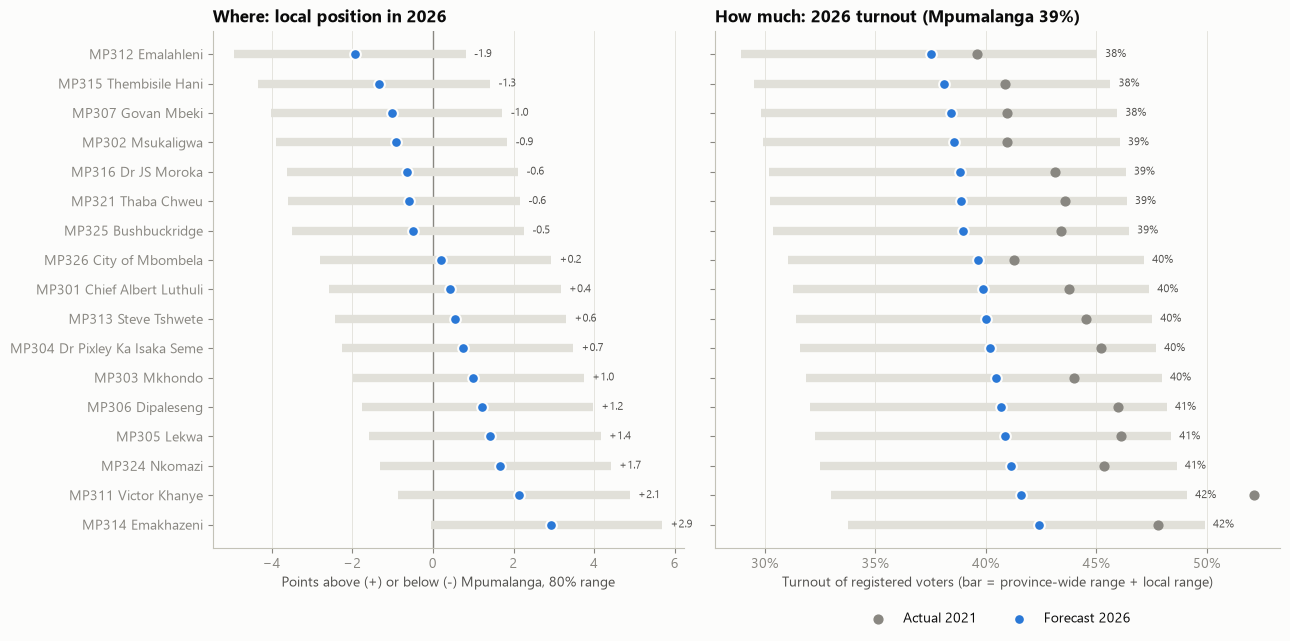

In [40]:
# =====================================================================================
# 5.5 Figure 8: 2026 forecast per municipality
# -------------------------------------------------------------------------------------
# HOW TO READ: left = WHERE: each municipality's predicted position relative to the
#        province (bar = 80% range from backtests). Left of zero = below the province.
#        Right = HOW MUCH: turnout forecast (blue dot), the range including the province-
#        wide uncertainty (bar), and actual 2021 turnout (grey dot).
#        Sorted with the lowest forecast at the top (the areas most at risk).
# SAVED AS: derived/figures/fig8_forecast_2026.png
# =====================================================================================
f = forecast_2026.sort_values('local_position_forecast', ascending=False)
labels = [f'{c} {names[c]}' for c in f.index]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6.5), sharey=True, gridspec_kw={'width_ratios': [1, 1.2]})
ax1.axvline(0, color=REFERENCE, linewidth=1)
ax1.hlines(labels, f['local_low_80'], f['local_high_80'], color=GRID, linewidth=6)
ax1.scatter(f['local_position_forecast'], labels, s=60, color=SERIES_1, edgecolor=SURFACE, linewidth=1.5, zorder=4)
for i, v in enumerate(f['local_position_forecast']):
    ax1.annotate(f'{v:+.1f}', (f['local_high_80'].iloc[i], i), xytext=(6, 0), textcoords='offset points', va='center', fontsize=8, color=INK_2)
ax1.set_xlabel('Points above (+) or below (-) Mpumalanga, 80% range')
ax1.set_title('Where: local position in 2026'); ax1.grid(axis='y', visible=False)

ax2.hlines(labels, f['range_low'], f['range_high'], color=GRID, linewidth=6)
ax2.scatter(f['turnout_2021'], labels, s=40, color=REFERENCE, zorder=3, label='Actual 2021')
ax2.scatter(f['turnout_2026_forecast'], labels, s=60, color=SERIES_1, edgecolor=SURFACE, linewidth=1.5, zorder=4, label='Forecast 2026')
for i, (c, row) in enumerate(f.iterrows()):
    ax2.annotate(f"{row['turnout_2026_forecast']:.0f}%", (row['range_high'], i), xytext=(6, 0), textcoords='offset points', va='center', fontsize=8, color=INK_2)
ax2.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0)); ax2.grid(axis='y', visible=False)
ax2.set_xlabel('Turnout of registered voters (bar = province-wide range + local range)')
ax2.set_title(f'How much: 2026 turnout (Mpumalanga {mp_2026:.0f}%)')
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
fig.tight_layout()
save(fig, 'fig8_forecast_2026')

Main gap in 2021: {'Registration': 11, 'Turnout': 6}


,voted_per_100,registered_not_voted_per_100,not_registered_per_100,main_gap,voted_per_100_2026_projection
municipality_code_2021,,,,,
MP303,19.0,24.2,56.8,Registration,17.3
MP302,21.4,30.8,47.8,Registration,19.9
MP304,22.2,26.9,50.9,Registration,20.7
MP315,22.3,32.3,45.4,Registration,20.4
MP324,22.7,27.3,50.0,Registration,20.9
MP325,23.6,30.8,45.6,Registration,21.8
MP326,25.0,35.5,39.5,Registration,24.3
MP312,25.7,39.2,35.1,Turnout,25.8
MP316,26.1,34.4,39.6,Registration,22.3


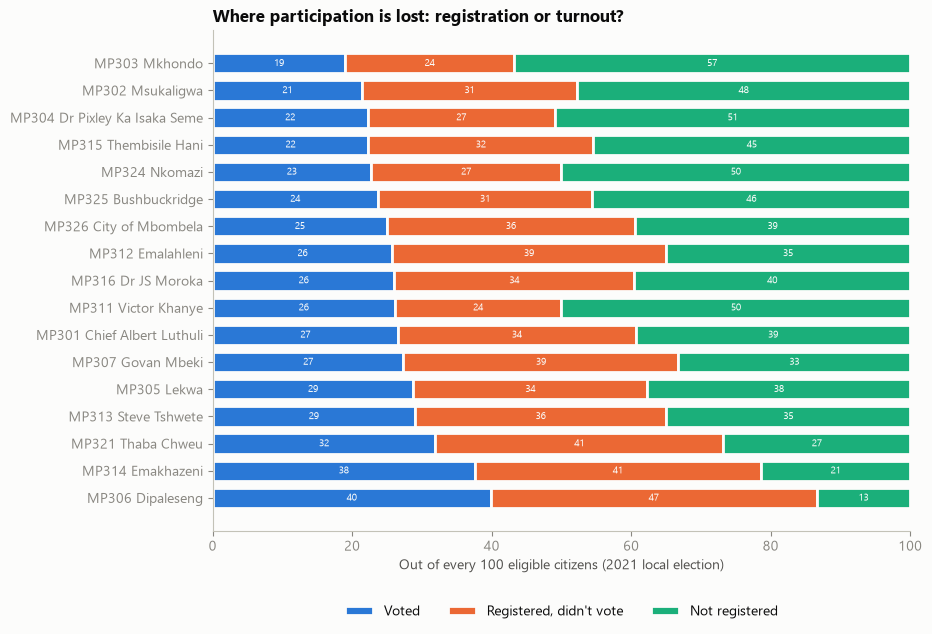

In [41]:
# =====================================================================================
# 5.6 Part B: registration gap vs turnout gap
# -------------------------------------------------------------------------------------
# WHAT:  For every 100 eligible citizens in each municipality (2021 election):
#          voted                      = 100 x registration rate x turnout
#          registered but didn't vote = 100 x registration rate x (1 - turnout)
#          not registered             = 100 x (1 - registration rate)
#        "Main gap" = whichever of the two lost groups is bigger.
#        2026 projection = 2026 registration rate x 2026 turnout forecast.
# WHY:   A registration gap calls for registration drives; a turnout gap calls for
#        mobilising people who are already registered. Different fixes.
# NOTE:  Registration rates above 100% (none in Mpumalanga) would be capped at 100.
# =====================================================================================
gap = muni_features[['municipality_name_2021', 'registration_rate_2021_pct', 'turnout_2021', 'registration_rate_2026_pct',
                     'youth_registration_rate_2026_pct', 'youth_registration_gap_pp']].copy()
R = (gap['registration_rate_2021_pct'] / 100).clip(upper=1)
T = gap['turnout_2021'] / 100
gap['voted_per_100'] = 100 * R * T
gap['registered_not_voted_per_100'] = 100 * R * (1 - T)
gap['not_registered_per_100'] = 100 * (1 - R)
gap['main_gap'] = np.where(gap['registered_not_voted_per_100'] > gap['not_registered_per_100'], 'Turnout', 'Registration')
gap = gap.join(forecast_2026[['turnout_2026_forecast']])
gap['voted_per_100_2026_projection'] = (gap['registration_rate_2026_pct'].clip(upper=100) * gap['turnout_2026_forecast'] / 100)
print(f"Main gap in 2021: {gap['main_gap'].value_counts().to_dict()}")
display(gap.sort_values('voted_per_100')[['voted_per_100', 'registered_not_voted_per_100', 'not_registered_per_100',
                                          'main_gap', 'voted_per_100_2026_projection']].round(1))

g2 = gap.sort_values('voted_per_100', ascending=False)
labels = [f'{c} {names[c]}' for c in g2.index]
fig, ax = plt.subplots(figsize=(9, 6.5))
left = np.zeros(len(g2))
for col, label, colour in [('voted_per_100', 'Voted', SERIES_1),
                           ('registered_not_voted_per_100', "Registered, didn't vote", SERIES_2),
                           ('not_registered_per_100', 'Not registered', '#1baf7a')]:
    ax.barh(labels, g2[col], left=left, color=colour, edgecolor=SURFACE, linewidth=2, height=0.75, label=label)
    for i, (v, l0) in enumerate(zip(g2[col], left)):
        if v >= 8:
            ax.text(l0 + v / 2, i, f'{v:.0f}', ha='center', va='center', fontsize=7.5, color=SURFACE)
    left = left + g2[col].to_numpy()
ax.set_xlim(0, 100); ax.grid(False)
ax.set_xlabel('Out of every 100 eligible citizens (2021 local election)')
ax.set_title('Where participation is lost: registration or turnout?')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3)
save(fig, 'fig9_registration_vs_turnout_gap')

,Turnout 2021,Turnout change 2016-21,"Voted, % of eligible 2021",Registration rate 2026,Youth registration gap 2026
Internet access,0.08,0.26,0.60,0.65,0.47
Owns a computer,-0.06,0.20,0.53,0.66,0.53
Owns a car,-0.02,0.43,0.58,0.64,0.44
Piped water in yard,0.50,0.41,0.55,0.44,0.21
Electricity for lighting,-0.01,-0.11,-0.04,-0.13,0.02
Flush toilet,0.37,0.38,0.59,0.55,0.41
Weekly refuse removal,0.38,0.40,0.53,0.48,0.38
Informal dwelling,0.04,0.44,0.42,0.40,0.18
RDP house,0.63,0.42,0.48,0.34,0.04
Adult hunger,-0.39,-0.13,-0.55,-0.50,-0.23


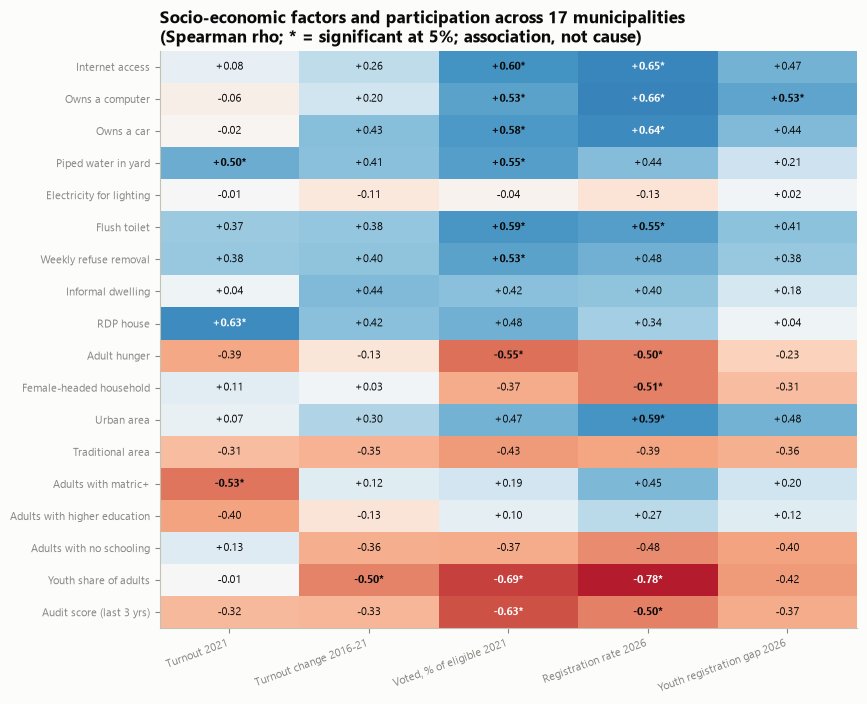

Significant associations (|rho| >= 0.48):


rho
Youth share of adults    Registration rate 2026      -0.78
                         Voted, % of eligible 2021   -0.69
Owns a computer          Registration rate 2026       0.66
Internet access          Registration rate 2026       0.65
Owns a car               Registration rate 2026       0.64
Audit score (last 3 yrs) Voted, % of eligible 2021   -0.63
RDP house                Turnout 2021                 0.63
Internet access          Voted, % of eligible 2021    0.60
Urban area               Registration rate 2026       0.59
Flush toilet             Voted, % of eligible 2021    0.59
Owns a car               Voted, % of eligible 2021    0.58
Flush toilet             Registration rate 2026       0.55
Piped water in yard      Voted, % of eligible 2021    0.55
Adult hunger             Voted, % of eligible 2021   -0.55
Owns a computer          Voted, % of eligible 2021    0.53
Weekly refuse removal    Voted, % of eligible 2021    0.53
Adults with matric+      Turnout 2021                -0.53
Owns a computer          Youth registration gap 2026  0.53
Female-headed household  Registration rate 2026      -0.51
Audit score (last 3 yrs) Registration rate 2026      -0.50
Adult hunger             Registration rate 2026      -0.50
Youth share of adults    Turnout change 2016-21      -0.50
Piped water in yard      Turnout 2021                 0.50

Does municipal context improve the forecast? (backtest average; lower MAE / higher rho is better)


,vd_MAE_pp,vd_rank_rho,muni_MAE_pp,muni_rank_rho
model,,,,
Gradient boosting,5.39,0.69,2.15,0.61
Gradient boosting + municipal context,5.43,0.70,2.29,0.63


What the local-position model relies on (sum of permutation importance by feature group, points):


,importance
"Turnout history, district size and spoilt ballots",2.124
Party competition,0.380


In [42]:
# =====================================================================================
# 5.7 Part C: which socio-economic factors go with low participation?
# -------------------------------------------------------------------------------------
# WHAT:  Answers the Day 1 question "which factors are associated with unequal
#        participation?" in two ways:
#        (1) Spearman rank correlation between each factor and five participation
#            outcomes, across the 17 municipalities (grid below; blue = higher factor goes
#            with higher outcome, red = lower). * marks |rho| >= 0.48, the 5% significance
#            level for 17 municipalities.
#        (2) Whether municipal context (Census 2022, audit record, provincial-election
#            turnout) improves the turnout forecast: backtest of 5.2, with and
#            without it, and what the local-position model relies on (5.4).
# CAUTION: association, NOT cause. The Census only identifies municipalities (not wards),
#        so socio-economic factors vary across just 17 places; employment and income are
#        not in the Census 10% sample.
# SAVED AS: derived/figures/fig10_factors_vs_participation.png
# =====================================================================================
FACTORS = {
    'c22_internet_any_pct': 'Internet access', 'c22_computer_pct': 'Owns a computer', 'c22_motor_car_pct': 'Owns a car',
    'c22_piped_water_in_yard_pct': 'Piped water in yard', 'c22_electricity_lighting_pct': 'Electricity for lighting',
    'c22_flush_toilet_pct': 'Flush toilet', 'c22_refuse_weekly_pct': 'Weekly refuse removal',
    'c22_informal_dwelling_pct': 'Informal dwelling', 'c22_rdp_house_pct': 'RDP house', 'c22_adult_hunger_pct': 'Adult hunger',
    'c22_female_headed_pct': 'Female-headed household', 'c22_urban_pct': 'Urban area', 'c22_traditional_pct': 'Traditional area',
    'c22_matric_or_higher_pct': 'Adults with matric+', 'c22_higher_education_pct': 'Adults with higher education',
    'c22_no_schooling_pct': 'Adults with no schooling', 'c22_youth_share_of_adults_pct': 'Youth share of adults',
    'audit_score_avg_last3': 'Audit score (last 3 yrs)',
}
OUTCOMES = {'turnout_2021': 'Turnout 2021', 'turnout_change_2016_2021_pp': 'Turnout change 2016-21',
            'participation_2021_pct': 'Voted, % of eligible 2021', 'registration_rate_2026_pct': 'Registration rate 2026',
            'youth_registration_gap_pp': 'Youth registration gap 2026'}
SIG = 0.48
fx = muni_features[list(FACTORS)].rename(columns=FACTORS)
oc = muni_features[list(OUTCOMES)].rename(columns=OUTCOMES)
factor_corr = pd.DataFrame({o: fx.corrwith(oc[o], method='spearman') for o in oc.columns})
display(factor_corr.round(2))

fig, ax = plt.subplots(figsize=(9, 7.5))
ax.imshow(factor_corr.to_numpy(), cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
for i in range(factor_corr.shape[0]):
    for j in range(factor_corr.shape[1]):
        v = factor_corr.iat[i, j]
        ax.text(j, i, f"{v:+.2f}{'*' if abs(v) >= SIG else ''}", ha='center', va='center', fontsize=8,
                color=SURFACE if abs(v) >= 0.6 else INK, fontweight='bold' if abs(v) >= SIG else 'normal')
ax.set_xticks(range(factor_corr.shape[1]), factor_corr.columns, rotation=20, ha='right', fontsize=8)
ax.set_yticks(range(factor_corr.shape[0]), factor_corr.index, fontsize=8)
ax.grid(False)
ax.set_title('Socio-economic factors and participation across 17 municipalities\n(Spearman rho; * = significant at 5%; association, not cause)')
save(fig, 'fig10_factors_vs_participation')

strong = factor_corr.stack()[lambda s: s.abs() >= SIG].sort_values(key=abs, ascending=False)
print('Significant associations (|rho| >= 0.48):')
display(strong.round(2).rename('rho').to_frame())

if 'local_summary' in globals():
    ctx = local_summary.loc[['Gradient boosting', 'Gradient boosting + municipal context'],
                            ['vd_MAE_pp', 'vd_rank_rho', 'muni_MAE_pp', 'muni_rank_rho']]
    print('Does municipal context improve the forecast? (backtest average; lower MAE / higher rho is better)')
    display(ctx.round(2))
if 'importance' in globals():
    group = np.where(importance.index.str.startswith(('vd_enp', 'vd_winner', 'vd_margin', 'vd_anc')),
                     'Party competition', 'Turnout history, district size and spoilt ballots')
    grouped = importance.groupby(group).sum().sort_values(ascending=False)
    print('What the local-position model relies on (sum of permutation importance by feature group, points):')
    display(grouped.round(3).rename('importance').to_frame())

In [43]:
# =====================================================================================
# 5.8 Part D: participation profiles (clustering the 17 municipalities)
# -------------------------------------------------------------------------------------
# WHAT:  Groups municipalities with similar participation patterns using k-means on
#        standardised indicators (turnout, turnout change, registration, youth gap, youth
#        share of roll, audit score, 2024 provincial turnout, hunger, urban share, water).
# HOW MANY GROUPS: k = 2..5 compared with the silhouette score (higher = clearer groups).
# STABILITY: the grouping is re-run 50 times with different random starts, and 50 times on
#        resampled municipalities. The adjusted Rand index (1 = identical groups) shows
#        whether the groups are real or an accident of the settings.
# NAMES: each profile is named from the indicators where it differs most from average.
# CAUTION: 17 municipalities is a small group; profiles are descriptive, not causal.
# =====================================================================================
PROFILE_COLS = ['turnout_2021', 'turnout_change_2016_2021_pp', 'registration_rate_2026_pct', 'youth_registration_gap_pp',
                'youth_share_of_roll_2026_pct', 'audit_score_avg_last3', 'c22_adult_hunger_pct', 'c22_urban_pct', 'c22_piped_water_in_yard_pct']
prof = muni_features[PROFILE_COLS].join(npe_turnout[2024].rename('npe_turnout_2024'))
Z = (prof - prof.mean()) / prof.std()
sil = {k: silhouette_score(Z, KMeans(n_clusters=k, n_init=20, random_state=RANDOM_SEED).fit_predict(Z)) for k in range(2, 6)}
K = max(sil, key=sil.get)
print('Silhouette by k:', {k: round(v, 3) for k, v in sil.items()}, '-> chosen k =', K)
km = KMeans(n_clusters=K, n_init=50, random_state=RANDOM_SEED).fit(Z)
labels_ref = km.labels_
rng = np.random.default_rng(RANDOM_SEED)
seed_ari = [adjusted_rand_score(labels_ref, KMeans(n_clusters=K, n_init=1, random_state=s).fit_predict(Z)) for s in range(50)]
boot_ari = []
for _ in range(50):
    idx = rng.choice(len(Z), size=len(Z), replace=True)
    lab = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_SEED).fit(Z.iloc[idx]).predict(Z)
    boot_ari.append(adjusted_rand_score(labels_ref, lab))
print(f'Stability (adjusted Rand index): different starts {np.mean(seed_ari):.2f}, resampled municipalities {np.mean(boot_ari):.2f}')

centres = pd.DataFrame(km.cluster_centers_, columns=Z.columns)
NICE = {'turnout_2021': 'turnout', 'turnout_change_2016_2021_pp': 'turnout change', 'registration_rate_2026_pct': 'registration',
        'youth_registration_gap_pp': 'youth gap', 'youth_share_of_roll_2026_pct': 'youth share', 'audit_score_avg_last3': 'audit score',
        'c22_adult_hunger_pct': 'hunger', 'c22_urban_pct': 'urban', 'c22_piped_water_in_yard_pct': 'piped water', 'npe_turnout_2024': '2024 turnout'}
def profile_name(row):
    top = row.abs().sort_values(ascending=False).index[:2]
    return ' / '.join(('high ' if row[c] > 0 else 'low ') + NICE[c] for c in top)
profile_names = {i: f'Profile {i + 1}: {profile_name(centres.loc[i])}' for i in centres.index}
profiles = prof.assign(profile=[profile_names[l] for l in labels_ref]).join(muni_features[['municipality_name_2021']])
display(profiles.groupby('profile')[prof.columns].mean().round(1).T)
display(profiles[['municipality_name_2021', 'profile']].sort_values('profile'))

Silhouette by k: {2: 0.238, 3: 0.202, 4: 0.158, 5: 0.19} -> chosen k = 2


Stability (adjusted Rand index): different starts 0.77, resampled municipalities 0.69


profile,Profile 1: low urban / low registration,Profile 2: high urban / high registration
turnout_2021,43.1,45.1
turnout_change_2016_2021_pp,-14.6,-10.2
registration_rate_2026_pct,53.7,68.5
youth_registration_gap_pp,22.0,28.0
youth_share_of_roll_2026_pct,20.6,17.8
audit_score_avg_last3,2.7,2.0
c22_adult_hunger_pct,19.1,15.6
c22_urban_pct,34.2,91.4
c22_piped_water_in_yard_pct,77.4,90.1
npe_turnout_2024,57.5,57.4


,municipality_name_2021,profile
municipality_code_2021,,
MP301,MP301 - Chief Albert Luthuli,Profile 1: low urban / low registration
MP302,MP302 - Msukaligwa,Profile 1: low urban / low registration
MP303,MP303 - Mkhondo,Profile 1: low urban / low registration
MP304,MP304 - Dr Pixley Ka Isaka Seme,Profile 1: low urban / low registration
MP315,MP315 - Thembisile Hani,Profile 1: low urban / low registration
MP316,MP316 - Dr JS Moroka,Profile 1: low urban / low registration
MP324,MP324 - Nkomazi,Profile 1: low urban / low registration
MP325,MP325 - Bushbuckridge,Profile 1: low urban / low registration
MP326,MP326 - City of Mbombela,Profile 1: low urban / low registration


Sensitivity of the ranking to other weightings:


,weighting,rank_correlation,same_top5
0,equal weights,0.93,4
1,turnout-heavy,0.89,5
2,youth-heavy,0.90,3
3,no audit,0.81,5


,rank,municipality_name_2021,priority_score,value_low_turnout_forecast,value_youth_gap,value_low_registration,value_weak_audit,profile
municipality_code_2021,,,,,,,,
MP307,1,MP307 - Govan Mbeki,70.3,38.4,33.8,66.3,2.0,Profile 2: high urban / high registration
MP316,2,MP316 - Dr JS Moroka,66.7,38.8,29.1,57.3,2.0,Profile 1: low urban / low registration
MP312,3,MP312 - Emalahleni,63.7,37.5,26.7,68.8,2.3,Profile 2: high urban / high registration
MP302,4,MP302 - Msukaligwa,62.5,38.6,21.1,51.6,2.0,Profile 1: low urban / low registration
MP315,5,MP315 - Thembisile Hani,61.8,38.1,29.3,53.4,3.0,Profile 1: low urban / low registration
MP305,6,MP305 - Lekwa,57.4,40.9,28.7,61.6,1.3,Profile 2: high urban / high registration
MP313,7,MP313 - Steve Tshwete,51.3,40.0,30.5,66.0,2.3,Profile 2: high urban / high registration
MP301,8,MP301 - Chief Albert Luthuli,49.9,39.9,21.6,59.0,2.0,Profile 1: low urban / low registration
MP306,9,MP306 - Dipaleseng,49.3,40.7,37.1,83.6,2.0,Profile 2: high urban / high registration


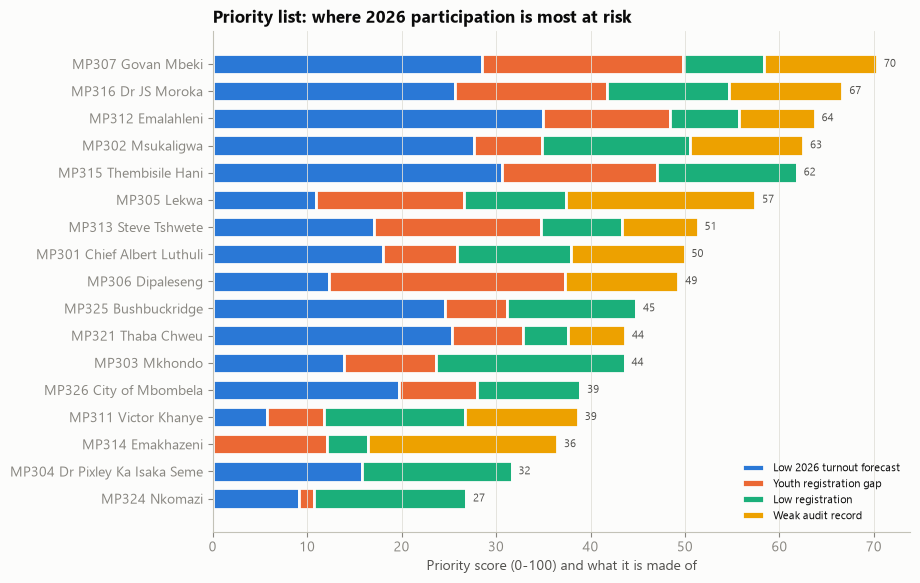

In [44]:
# =====================================================================================
# 5.9 Part D: priority list (transparent score)
# -------------------------------------------------------------------------------------
# WHAT:  One score from 0 to 100 per municipality. Each component is rescaled 0-1 across
#        the 17 municipalities, then weighted:
#          low 2026 turnout forecast      35%
#          large youth registration gap   25%
#          low 2026 registration rate     20%
#          weak audit record (3-yr avg)   20%
# WHY:   A clear, adjustable way to say where outreach is most needed. The weights are
#        a team judgement and are shown; the sensitivity check tests other weightings.
# =====================================================================================
comp = pd.DataFrame({
    'low_turnout_forecast': forecast_2026['turnout_2026_forecast'],
    'youth_gap': muni_features['youth_registration_gap_pp'],
    'low_registration': muni_features['registration_rate_2026_pct'],
    'weak_audit': muni_features['audit_score_avg_last3'],
})
scaled = (comp - comp.min()) / (comp.max() - comp.min())
for c in ['low_turnout_forecast', 'low_registration', 'weak_audit']:      # low values = high priority
    scaled[c] = 1 - scaled[c]
WEIGHTS = {'low_turnout_forecast': 0.35, 'youth_gap': 0.25, 'low_registration': 0.20, 'weak_audit': 0.20}
contrib = scaled.mul(pd.Series(WEIGHTS)) * 100
priority = contrib.assign(priority_score=contrib.sum(axis=1)).join(comp.add_prefix('value_'))
priority = priority.join(muni_features[['municipality_name_2021']]).join(profiles['profile'])
priority = priority.sort_values('priority_score', ascending=False)
priority['rank'] = np.arange(1, len(priority) + 1)

ALTERNATIVES = {'equal weights': dict.fromkeys(WEIGHTS, 0.25),
                'turnout-heavy': {'low_turnout_forecast': 0.6, 'youth_gap': 0.2, 'low_registration': 0.1, 'weak_audit': 0.1},
                'youth-heavy': {'low_turnout_forecast': 0.2, 'youth_gap': 0.5, 'low_registration': 0.2, 'weak_audit': 0.1},
                'no audit': {'low_turnout_forecast': 0.45, 'youth_gap': 0.3, 'low_registration': 0.25, 'weak_audit': 0.0}}
top5 = set(priority.index[:5])
sens = []
for name, w in ALTERNATIVES.items():
    alt = scaled.mul(pd.Series(w)).sum(axis=1)
    sens.append({'weighting': name, 'rank_correlation': alt.corr(priority['priority_score'], method='spearman'),
                 'same_top5': len(top5 & set(alt.nlargest(5).index))})
print('Sensitivity of the ranking to other weightings:')
display(pd.DataFrame(sens).round(2))
display(priority[['rank', 'municipality_name_2021', 'priority_score', 'value_low_turnout_forecast', 'value_youth_gap',
                  'value_low_registration', 'value_weak_audit', 'profile']].round(1))

p2 = priority.iloc[::-1]
labels = [f'{c} {names[c]}' for c in p2.index]
fig, ax = plt.subplots(figsize=(9, 6.5))
left = np.zeros(len(p2))
for col, label, colour in [('low_turnout_forecast', 'Low 2026 turnout forecast', SERIES_1), ('youth_gap', 'Youth registration gap', SERIES_2),
                           ('low_registration', 'Low registration', '#1baf7a'), ('weak_audit', 'Weak audit record', '#eda100')]:
    ax.barh(labels, p2[col], left=left, color=colour, edgecolor=SURFACE, linewidth=2, height=0.75, label=label)
    left = left + p2[col].to_numpy()
for i, v in enumerate(p2['priority_score']):
    ax.annotate(f'{v:.0f}', (v, i), xytext=(5, 0), textcoords='offset points', va='center', fontsize=8, color=INK_2)
ax.grid(axis='y', visible=False)
ax.set_xlabel('Priority score (0-100) and what it is made of')
ax.set_title('Priority list: where 2026 participation is most at risk')
ax.legend(loc='lower right', fontsize=8)
save(fig, 'fig11_priority_list')

In [45]:
# =====================================================================================
# 5.10 Save Stage 5 outputs (tables, model, and a summary for the dashboard)
# -------------------------------------------------------------------------------------
# SAVES: derived/model_backtest.csv (turnout: three approaches x three backtests),
#        derived/model_backtest_local.csv, derived/model_backtest_province.csv,
#        derived/forecast_2026_voting_district.csv, derived/forecast_2026_municipality.csv,
#        derived/forecast_2026_province_scenarios.csv, derived/gap_breakdown.csv,
#        derived/participation_profiles.csv, derived/priority_list.csv,
#        derived/models/turnout_model.joblib (+ turnout_model_info.json)
# DASHBOARD: turnout = chosen province level + local_position_forecast, so a slider can
#        move the province level and redraw every district.
# =====================================================================================
MODEL_DIR = DERIVED_DIR / 'models'
MODEL_DIR.mkdir(exist_ok=True)
backtest.to_csv(DERIVED_DIR / 'model_backtest.csv', index=False)
local_backtest.to_csv(DERIVED_DIR / 'model_backtest_local.csv', index=False)
province_backtest.to_csv(DERIVED_DIR / 'model_backtest_province.csv', index=False)
future[['voting_district', 'municipality_code_2021', 'municipality_name_2021', 'registered_voters', 'vd_turnout_lag1',
        'local_position_forecast', 'turnout_forecast', 'at_risk_district']].round(3).to_csv(
    DERIVED_DIR / 'forecast_2026_voting_district.csv', index=False)
forecast_2026.round(3).to_csv(DERIVED_DIR / 'forecast_2026_municipality.csv')
province_scenarios.round(3).to_csv(DERIVED_DIR / 'forecast_2026_province_scenarios.csv', index=False)
gap.round(3).to_csv(DERIVED_DIR / 'gap_breakdown.csv')
profiles.round(3).to_csv(DERIVED_DIR / 'participation_profiles.csv')
priority.round(3).to_csv(DERIVED_DIR / 'priority_list.csv')
if final_model is not None:
    joblib.dump({'gradient_boosting': final_model, 'shrink_factor': shrink_all, 'local_model': LOCAL_MODEL,
                 'features': final_model.used_features_}, MODEL_DIR / 'turnout_model.joblib')
info = {'approach': 'two-step: province-wide level + local position',
        'province_method': PROVINCE_METHOD, 'local_model': LOCAL_MODEL,
        'local_features': final_model.used_features_ if final_model is not None else ['vd_rel_lag1', 'muni_rel_lag1'],
        'shrink_factor': round(shrink_all, 4),
        'trained_on_target_years': sorted(history.target_year.unique().tolist()),
        'backtest_turnout_average': backtest_summary.round(3).reset_index().to_dict(orient='records'),
        'backtest_local_average': local_summary.round(3).reset_index().to_dict(orient='records'),
        'local_interval_80_error_pp': [round(float(lo_err), 3), round(float(hi_err), 3)],
        'province_2026_pct': {'central': round(float(province_2026), 2), 'low': round(float(province_low), 2),
                              'high': round(float(province_high), 2)},
        'mpumalanga_turnout_2026_forecast_pct': round(float(mp_2026), 2), 'priority_weights': WEIGHTS,
        'profiles_k': int(K), 'created': datetime.now(timezone.utc).isoformat(timespec='seconds')}
(MODEL_DIR / 'turnout_model_info.json').write_text(json.dumps(info, indent=2), encoding='utf-8')
for f in sorted(p.name for p in DERIVED_DIR.glob('*.csv') if p.stem.startswith(('model_', 'forecast_', 'gap_', 'participation_', 'priority_'))):
    print(f'{f:42s} {(DERIVED_DIR / f).stat().st_size:>9,} bytes')
print('Model files:', sorted(p.name for p in MODEL_DIR.iterdir()))
print('Stage 5 complete.')

forecast_2026_municipality.csv                 1,705 bytes
forecast_2026_province_scenarios.csv             213 bytes
forecast_2026_voting_district.csv            125,238 bytes
gap_breakdown.csv                              2,143 bytes
model_backtest.csv                             1,406 bytes
model_backtest_local.csv                       2,673 bytes
model_backtest_province.csv                      552 bytes
participation_profiles.csv                     2,601 bytes
priority_list.csv                              2,379 bytes
Model files: ['turnout_model.joblib', 'turnout_model_info.json']
Stage 5 complete.


## Limitations

| Limitation | Effect | How it is handled |
|---|---|---|
| 2026 eligible-citizen counts come from Census 2022 aged forward; deaths and migration after Feb 2022 are not removed | 2026 registration rates are lower bounds; the youth-vs-older gap is understated | Stated; the youth rate (low mortality) is the most reliable |
| About 16.5% of Census households skipped the household-goods, internet and hunger questions (6-35% by municipality) | Those indicators rest on answering households only | Answer rates kept next to every indicator (`*_answered_pct`) |
| The Census 10% sample identifies municipalities, not wards or voting districts | Socio-economic factors vary across only 17 places | Correlations reported as association with a significance threshold; never as cause |
| Employment and income were withheld from the Census 10% sample by Stats SA | These factors cannot be tested | Stated |
| Census 2022 is later than the 2006-2021 elections it is used with | Context features are a later snapshot for past elections | Stated in the feature dictionary; history features carry most of the signal |
| Online-registration and age-level turnout figures exist only nationally or provincially | They cannot be model inputs | Used as context only (`iec_2026_registration_press_figures.csv`) |
| No municipal youth registration history before 2026 | Youth cannot be a forecast feature | Youth enters the gap breakdown and priority list instead |
| Only three backtests (2011, 2016, 2021) and four past local/provincial turnout ratios | The province-wide level is the most uncertain part of the forecast | Forecast in two steps: the local picture (well tested on 1,800 districts) is kept separate from the province-wide level, which is shown as a range of scenarios |
| Party competition uses the PR-ballot result of the previous local election; 2024 national results by voting district were not available | The 2024 shift in party support is not in the local model | 2024 provincial-election turnout enters the province-wide level instead |
| MEC7 votes are not in the raw result files | Our turnout runs slightly above official turnout | Reconciled against official IEC reports (Stage 2) |
| Ward councillor, party registration and by-election data were not downloadable from the IEC during the project | Representation analysis not included | Stated |
| One 2000 record has spoilt votes recorded as NULL; MP325's 2021 official report differs slightly from the results file | Negligible | Documented in Stage 2 |

## References

**Data**
- Electoral Commission of South Africa (IEC): detailed Local Government Election results 2000-2021 and turnout reports, https://results.elections.org.za; voter registration statistics (as of 23 Sep 2026), https://www.elections.org.za/pw/StatsData/Voter-Registration-Statistics; provincial-election turnout reports 2004-2024.
- Statistics South Africa: Census 2022 Ten Percent Sample (households, persons, geography) and its metadata (report 03-01-47), https://isibaloweb.statssa.gov.za/pages/surveys/pss/censuses/2022/census2022.php
- Auditor-General of South Africa audit outcomes via National Treasury Municipal Money (`audit_opinions` cube), https://municipaldata.treasury.gov.za
- IEC statements reported by ITWeb, Joburg ETC, Independent on Saturday and GroundUp (context figures; every URL is in `DATASETS/reference/iec_2026_registration_press_figures.csv`).

**Software** (exact versions printed by the next cell): Python, pandas, NumPy, scikit-learn (Ridge, HistGradientBoostingRegressor, KMeans, permutation importance), matplotlib, pyarrow, openpyxl, joblib, threadpoolctl.

In [46]:
# =====================================================================================
# 5.11 Package versions used for this run (for the References section)
# =====================================================================================
versions = {'python': sys.version.split()[0]}
for pkg in ['pandas', 'numpy', 'scikit-learn', 'matplotlib', 'pyarrow', 'openpyxl', 'joblib', 'threadpoolctl']:
    try:
        versions[pkg] = importlib.metadata.version(pkg)
    except importlib.metadata.PackageNotFoundError:
        versions[pkg] = 'not installed'
display(pd.Series(versions, name='version').to_frame())

,version
python,3.13.6
pandas,3.0.6
numpy,2.5.3
scikit-learn,1.9.1
matplotlib,3.11.2
pyarrow,25.0.1
openpyxl,3.1.5
joblib,1.6.0
threadpoolctl,3.7.0
